# Neural Networks ML for image classification

## Dependencies

In [1]:
import time
global_start_time = time.time()

In [2]:
%pip install matplotlib
%pip install numpy
%pip install torch

## Reproducibility

In [3]:
import numpy as np, random, torch
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

torch.use_deterministic_algorithms(True)

## Exploratory Data Analysis

In [4]:
# General settings for plots

import matplotlib.pyplot as plt

# white background (general)
plt.rcParams['figure.facecolor'] = 'white'
# white background (inside plot)
plt.rcParams['axes.facecolor'] = 'white'
# white background also when saving plots
plt.rcParams['savefig.facecolor'] = 'white'

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
Number of classes: 4

- Baroque: 3307  samples
- Impressionism: 3307  samples
- Cubism: 3307  samples
- Abstract_Expressionism: 3307  samples

Total: 13228 samples



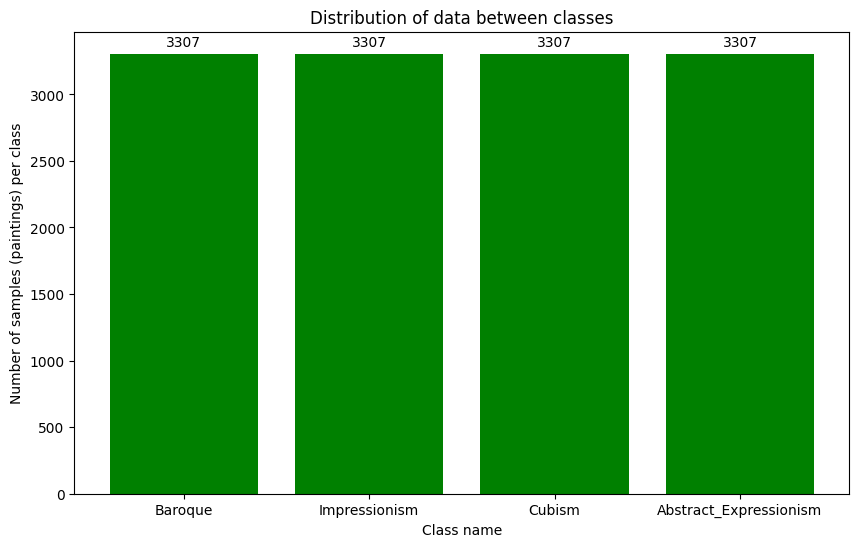

In [5]:
from google.colab import drive
drive.mount('/content/drive/')
data = np.load('/content/drive/MyDrive/wikiart_hw2_balanced.npz')

# local
# data = np.load('wikiart_hw2_balanced.npz')

X = data["X"]
Y = data["y"]
class_names = data["class_names"]

counts = {}
for i in range(4):
    counts[class_names[i]] = np.sum(Y == i)


print(f"Number of classes: {len(class_names)}\n")

for class_name in class_names:
    print(f"- {class_name}: {counts[class_name]}  samples")
print(f"\nTotal: {sum(counts.values())} samples\n")

plt.figure(figsize=(10,6))
plt.bar(counts.keys(), counts.values(), color='green')
plt.title("Distribution of data between classes")
plt.xlabel("Class name")
plt.ylabel("Number of samples (paintings) per class")
plt.bar_label(plt.bar(counts.keys(), counts.values(), color='green'), padding=3)
plt.show()

## Device Selection

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Tensor Preparation

In [7]:
# loading data into tensors

x_tensor = torch.tensor(X, dtype=torch.float32) / 255.0
x_tensor = x_tensor.permute(0, 3, 1, 2)

y_tensor = torch.tensor(Y, dtype=torch.int64)

print(f"x tensor: {x_tensor.shape}")
print(f"y tensor: {y_tensor.shape}")

x tensor: torch.Size([13228, 3, 32, 32])
y tensor: torch.Size([13228])


## Train, Validation, and Test Split

Train split: x:torch.Size([10228, 3, 32, 32]) y:torch.Size([10228])
  - Baroque: 2557
  - Impressionism: 2557
  - Cubism: 2557
  - Abstract_Expressionism: 2557
Val split:   x:torch.Size([1500, 3, 32, 32]) y:torch.Size([1500])
  - Baroque: 375
  - Impressionism: 375
  - Cubism: 375
  - Abstract_Expressionism: 375
Test split:  x:torch.Size([1500, 3, 32, 32]) y:torch.Size([1500])
  - Baroque: 375
  - Impressionism: 375
  - Cubism: 375
  - Abstract_Expressionism: 375


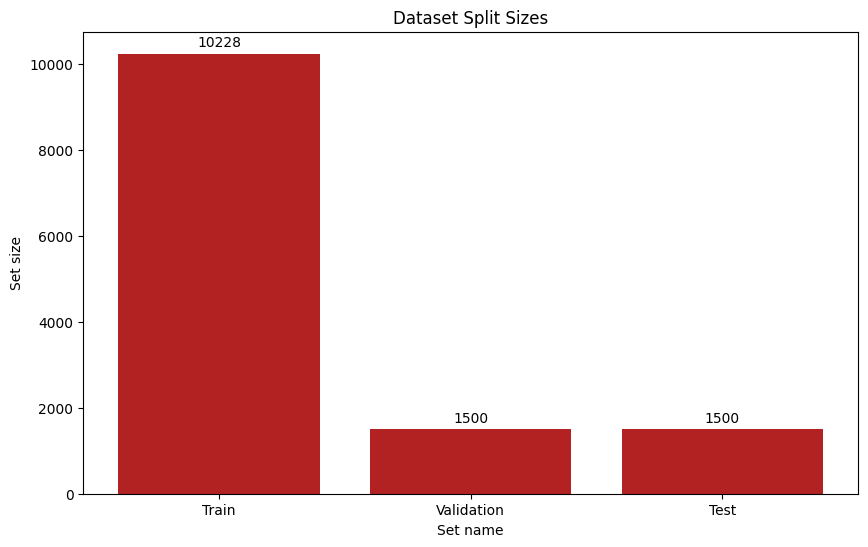

In [8]:
from sklearn.model_selection import train_test_split

# 1st split to create training data
x_train, x_temp, y_train, y_temp = train_test_split(x_tensor, y_tensor, test_size=0.2267916540671303, random_state=SEED, stratify=y_tensor)

# 2nd split to create validation and test data
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp)

print(f"Train split: x:{x_train.shape} y:{y_train.shape}")
for i in range(4):
    print(f"  - {class_names[i]}: {(y_train==i).sum().item()}")
print(f"Val split:   x:{x_val.shape} y:{y_val.shape}")
for i in range(4):
    print(f"  - {class_names[i]}: {(y_val==i).sum().item()}")
print(f"Test split:  x:{x_test.shape} y:{y_test.shape}")
for i in range(4):
    print(f"  - {class_names[i]}: {(y_test==i).sum().item()}")

plt.figure(figsize=(10, 6))
plt.bar(["Train", "Validation", "Test"], [x_train.shape[0], x_val.shape[0], x_test.shape[0]], color='firebrick')
plt.title("Dataset Split Sizes")
plt.xlabel("Set name")
plt.ylabel("Set size")
plt.bar_label(plt.bar(["Train", "Validation", "Test"], [x_train.shape[0], x_val.shape[0], x_test.shape[0]], color='firebrick'), padding=3)
plt.show()

## Datasets and DataLoaders

In [9]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 16

# datasets(for dataloaders)
train_dataset = TensorDataset(x_train, y_train)
val_dataset = TensorDataset(x_val, y_val)
test_dataset = TensorDataset(x_test, y_test)

# necessary for reproducibility
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

# dataloaders
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=g, worker_init_fn=seed_worker)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# debugging
print(f"Train batches: {len(train_dataloader)}")
print(f"Validation batches: {len(val_dataloader)}")
print(f"Test batches: {len(test_dataloader)}")

Train batches: 640
Validation batches: 94
Test batches: 94


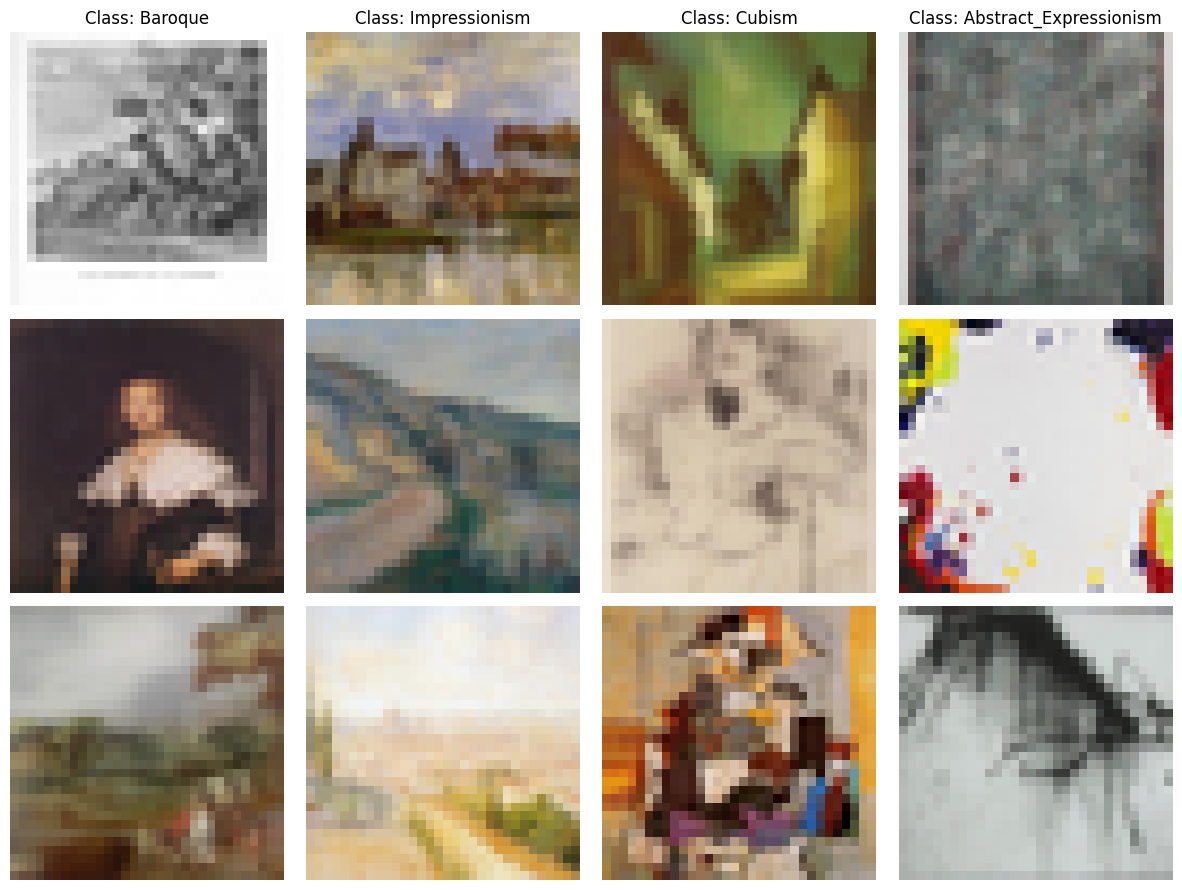

In [10]:
# a few samples

samples_per_class = {0: [], 1: [], 2: [], 3: []}

for i in range(len(y_tensor)):
    label = y_tensor[i].item()
    if len(samples_per_class[label]) < 3:
        samples_per_class[label].append(x_tensor[i])
    if all(len(images) == 3 for images in samples_per_class.values()):
        break

fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for class_idx in range(4):
    for sample_idx in range(3):
        img_tensor = samples_per_class[class_idx][sample_idx]
        img_np = img_tensor.permute(1, 2, 0).numpy()
        if img_np.max() > 1.0:
            img_np = img_np / 255.0
        img_np = np.clip(img_np, 0, 1)
        ax = axes[sample_idx, class_idx]
        ax.imshow(img_np)
        if sample_idx == 0:
            ax.set_title(f"Class: {class_names[class_idx]}")
        ax.axis("off")

plt.tight_layout()
plt.show()

## Visual Characteristics of the Dataset

The four classes differ mainly in color palette, contrast, texture, and composition. Baroque paintings often show dramatic light-dark contrast and recognizable subjects, Impressionism tends toward bright outdoor palettes and visible brushwork, Cubism emphasizes geometric fragmentation, and Abstract Expressionism is more non-representational. At 32x32 resolution, Cubism and Abstract Expressionism are likely to be the most difficult pair to separate because geometric edges and subject structure are heavily compressed.

## Training and Evaluation Utilities

In [11]:
import torch.nn as nn
from sklearn.metrics import f1_score, confusion_matrix

class baseline_FNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.linear_relu_stack = nn.Sequential(
            nn.Linear(in_features=3*32*32, out_features=128),
            nn.ReLU(),
            nn.Linear(in_features=128, out_features=32),
            nn.ReLU(),
            nn.Linear(in_features=32, out_features=4)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = baseline_FNN().to(device)
print(model)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for batch_idx, (images, labels) in enumerate(loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        # forward pass
        logits = model(images)
        # loss calculation
        loss = criterion(logits, labels)
        # backward pass
        loss.backward()
        # weights update
        optimizer.step()

        batch_size = images.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += batch_size

    epoch_loss = total_loss / total_samples
    epoch_acc = total_correct / total_samples

    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(loader):
            images = images.to(device)
            labels = labels.to(device)

            # forward pass
            logits = model(images)
            # loss calculation
            loss = criterion(logits, labels)

            batch_size = images.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_samples += batch_size

            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = total_loss / total_samples
    epoch_acc = total_correct / total_samples
    epoch_f1_macro = f1_score(all_labels, all_preds, average='macro')
    epoch_loss_cm = confusion_matrix(all_labels, all_preds)

    return epoch_loss, epoch_acc, epoch_f1_macro, epoch_loss_cm


baseline_FNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=3072, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=4, bias=True)
  )
)
Total parameters: 397,604
Trainable parameters: 397,604


## Feedforward Neural Network (Baseline) Training

In [12]:
from torch.optim import Adam

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
cpu_time = -1
gpu_time = -1

EPOCHS = 30
LEARNING_RATE = 0.001
optimizer = Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_f1': []
}

best_f1_val = -1
best_model_path = "best_baseline_fnn.pth"

print("Starting training...\n")

start_time = time.time()

for epoch in range(EPOCHS):
    # train (adjusting weights)
    train_loss, train_acc = train_one_epoch(model, train_dataloader, optimizer, criterion)

    # evaluate
    val_loss, val_acc, val_f1, val_cm = evaluate(model, val_dataloader, criterion)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    if val_f1>best_f1_val:
        best_f1_val = val_f1
        torch.save(model.state_dict(), best_model_path)

    # current epoch results
    print(f"Epoch [{epoch+1}/{EPOCHS}]  Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}% | Val macro F1: {val_f1:.4f}")
    print("-" * 100)
end_time = time.time()

print(f"Training complete!")
if device==torch.device("cpu"):
    cpu_time = end_time - start_time
    print(f"Time: {cpu_time:.4f} seconds")
else:
    gpu_time = end_time - start_time
    print(f"Time: {gpu_time:.4f} seconds")

Using device: cuda
Starting training...

Epoch [1/30]  Train Loss: 1.2966 | Train Acc: 40.03% | Val Loss: 1.2326 | Val Acc: 45.40% | Val macro F1: 0.4596
----------------------------------------------------------------------------------------------------
Epoch [2/30]  Train Loss: 1.2289 | Train Acc: 45.15% | Val Loss: 1.2223 | Val Acc: 47.40% | Val macro F1: 0.4676
----------------------------------------------------------------------------------------------------
Epoch [3/30]  Train Loss: 1.1980 | Train Acc: 47.00% | Val Loss: 1.2015 | Val Acc: 48.20% | Val macro F1: 0.4772
----------------------------------------------------------------------------------------------------
Epoch [4/30]  Train Loss: 1.1714 | Train Acc: 47.80% | Val Loss: 1.2059 | Val Acc: 44.27% | Val macro F1: 0.4238
----------------------------------------------------------------------------------------------------
Epoch [5/30]  Train Loss: 1.1494 | Train Acc: 49.06% | Val Loss: 1.1863 | Val Acc: 48.27% | Val macro F

## CPU Training Benchmark

In [13]:
device = torch.device("cpu")

if cpu_time == -1:
    print(">>> Started training using CPU...")

    model_cpu = baseline_FNN().to(device)
    optimizer_cpu = Adam(model_cpu.parameters(), lr=LEARNING_RATE)

    start_time = time.time()
    for epoch in range(EPOCHS):
        train_one_epoch(model_cpu, train_dataloader, optimizer_cpu, criterion)
    end_time = time.time()
    cpu_time = end_time - start_time
    print(f">>> CPU training complete! Time: {cpu_time:.2f} seconds")

# comparison
if gpu_time!=-1 and cpu_time!=-1:
    speedup = cpu_time / gpu_time
    quicker = "GPU" if speedup>1 else "CPU"
    slower = "CPU" if speedup>1 else "GPU"
    print(quicker + f" was {speedup:.4f} times quicker than the " + slower)
else:
    print("No GPU (CUDA) is available for training.")

# for safety
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

>>> Started training using CPU...
>>> CPU training complete! Time: 159.22 seconds
GPU was 3.0101 times quicker than the CPU


## Feedforward Baseline Test Evaluation

=======  Baseline FNN model evaluation on TEST SET  =======
Test Loss: 1.1143521954218547
Test Accuracy: 0.5533333333333333
Test macro F1: 0.554373927714883
Test Confusion matrix:
[210  74  52  39]
[ 29 235  64  47]
[ 32  97 162  84]
[ 21  49  82 223]



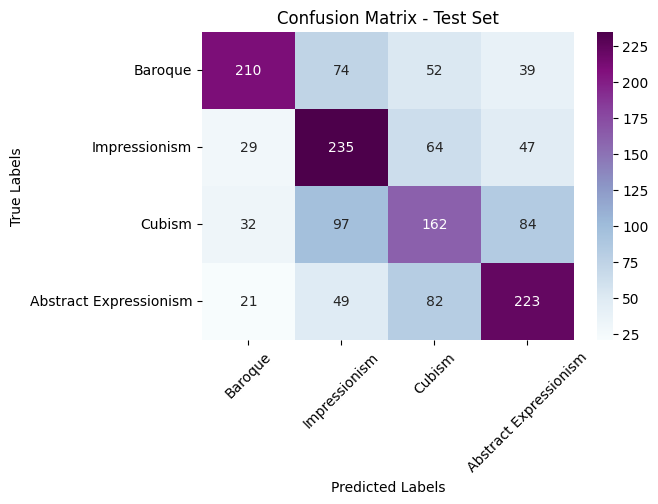


Total number of parameters: 397604


In [14]:
import seaborn as sns

best_model = baseline_FNN().to(device)
best_model.load_state_dict(torch.load("best_baseline_fnn.pth"))

test_loss, test_acc, test_f1, test_cm = evaluate(best_model, test_dataloader, criterion)

cm_fnn = test_cm

print("=======  Baseline FNN model evaluation on TEST SET  =======")
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_acc}")
print(f"Test macro F1: {test_f1}")
print(f"Test Confusion matrix:")
for row in test_cm:
    print(row)
print('')

class_names = ['Baroque', 'Impressionism', 'Cubism', 'Abstract Expressionism']

plt.figure(figsize=(6, 4))
sns.heatmap(test_cm, annot=True, fmt='d', cmap='BuPu',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

total_params = sum(p.numel() for p in best_model.parameters())
print(f"\nTotal number of parameters: {total_params}")

## Feedforward Baseline Learning Curves

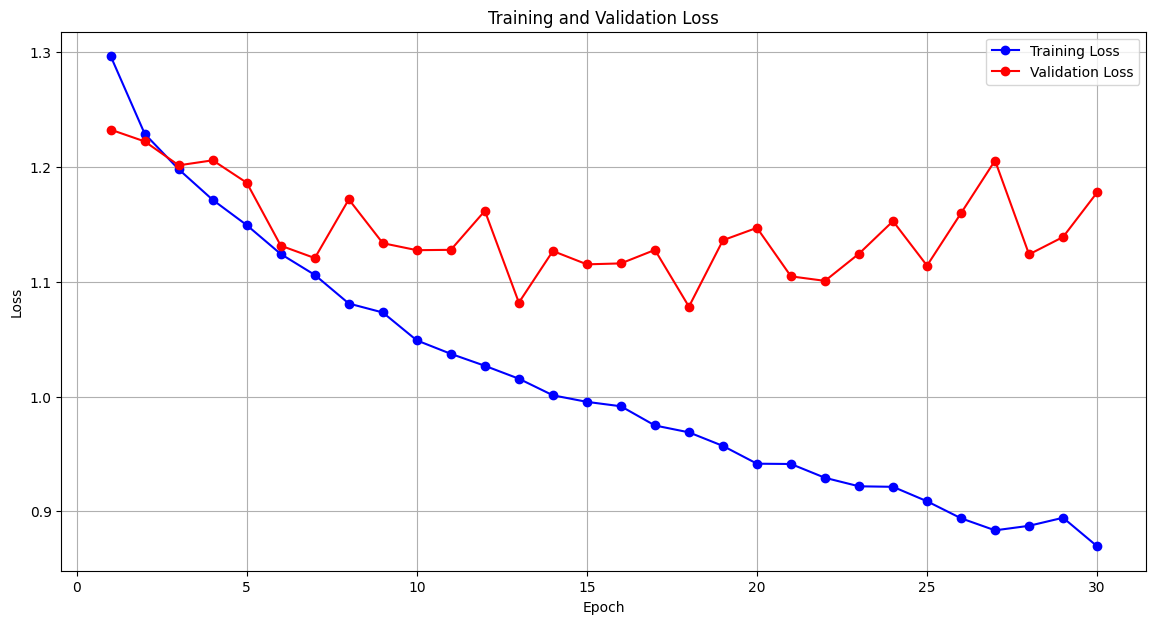

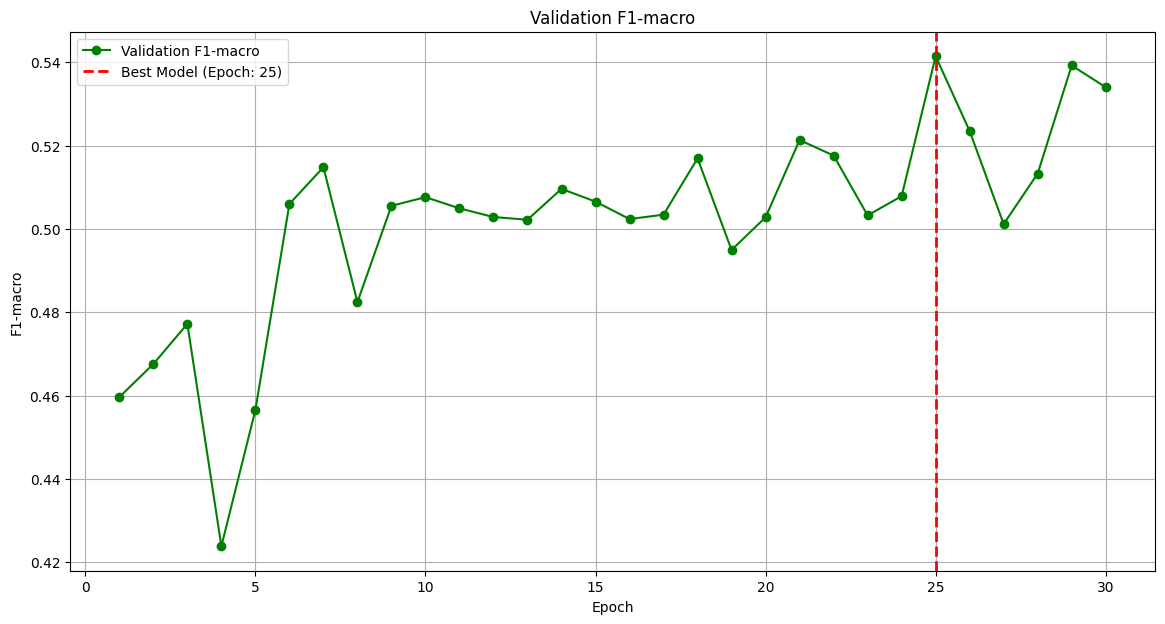

In [15]:
# loss
plt.figure(figsize=(14, 7))
plt.plot(range(1, len(history['train_loss'])+1), history['train_loss'], 'bo-', label='Training Loss')
plt.plot(range(1, len(history['val_loss'])+1), history['val_loss'], 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# f1-macro
plt.figure(figsize=(14, 7))
plt.plot(range(1, len(history['val_f1'])+1), history['val_f1'], 'go-', label='Validation F1-macro')
best_epoch = history['val_f1'].index(max(history['val_f1'])) + 1
plt.axvline(x=best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Model (Epoch: {best_epoch})')
plt.title('Validation F1-macro')
plt.xlabel('Epoch')
plt.ylabel('F1-macro')
plt.legend()
plt.grid(True)

## Generalization Behavior

The learning curves indicate overfitting: training loss continues to decrease while validation loss stops improving and becomes more variable. The validation F1 score reaches its best value around epoch 25, so that checkpoint is preferred over the final training epoch. Selecting the checkpoint using validation F1 preserves the model state with the strongest observed generalization rather than the lowest training loss.

## CPU vs GPU Speedup

The GPU was approximately 2-3x faster than the CPU for the feedforward training run. This is a meaningful improvement, but not an extreme speedup because the network is relatively small and the dataset contains low-resolution 32x32 images. For workloads of this scale, data loading and launch overhead limit GPU utilization; larger CNNs and batches generally benefit more from GPU parallelism.

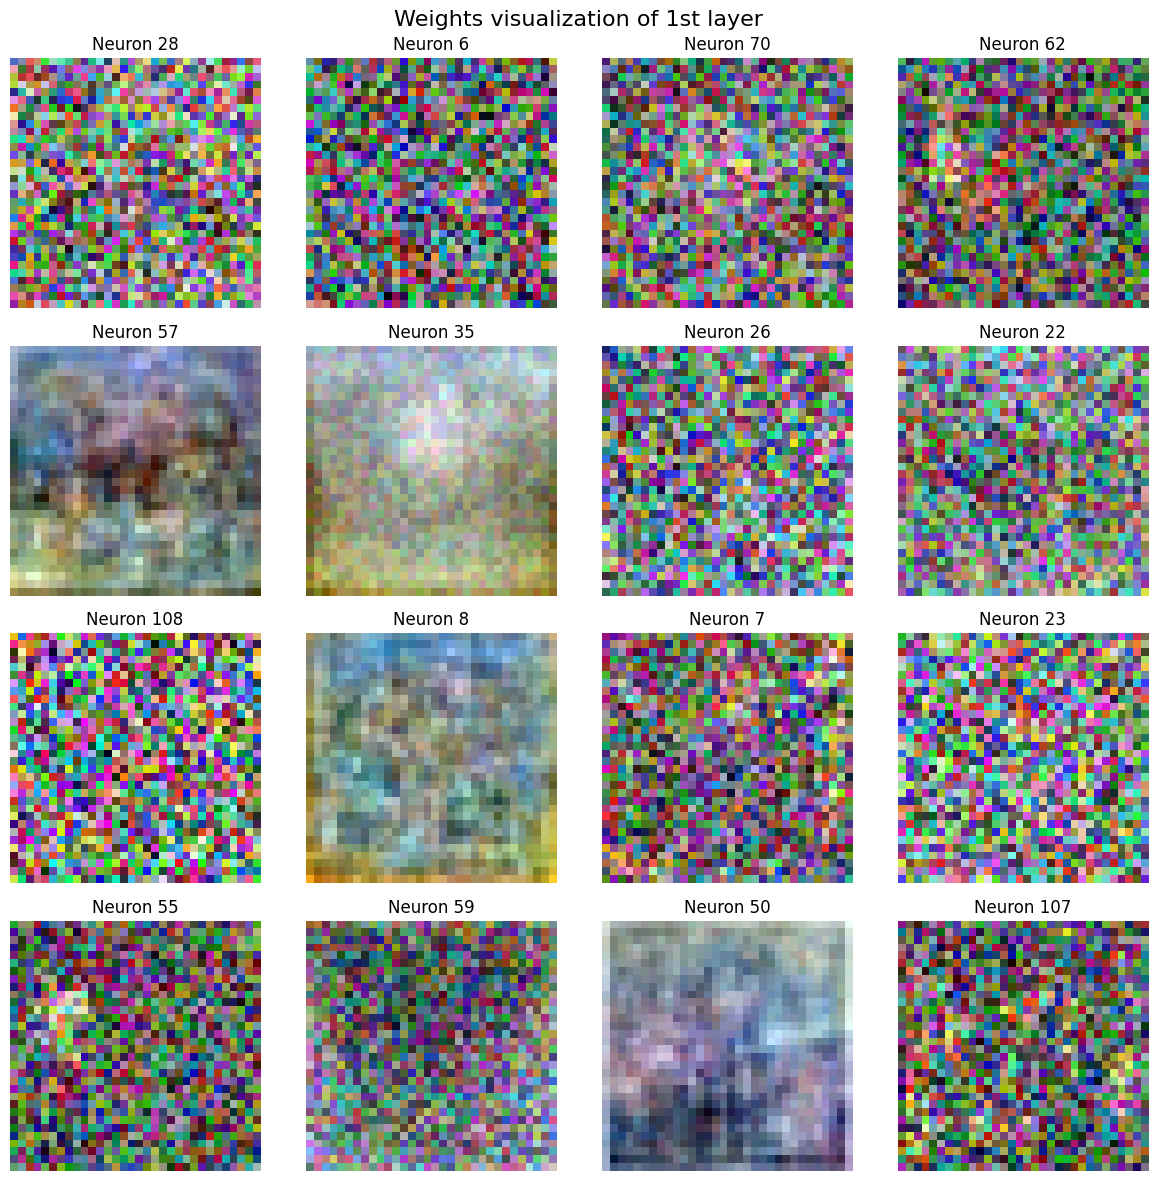

In [16]:
weights = best_model.linear_relu_stack[0].weight.data.cpu()

weights_reshaped = weights.view(128, 3, 32, 32)
random_neurons = random.sample(range(128), 16)  # choose 16 random neurons

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
axes = axes.flatten()

for i, neuron_idx in enumerate(random_neurons):
    w = weights_reshaped[neuron_idx]

    # Min-Max Scaling
    w_min = w.min()
    w_max = w.max()
    w_norm = (w - w_min) / (w_max - w_min)

    w_img = w_norm.permute(1, 2, 0).numpy()

    axes[i].imshow(w_img)
    axes[i].axis('off')
    axes[i].set_title(f'Neuron {neuron_idx}')

plt.suptitle("Weights visualization of 1st layer", fontsize=16)
plt.tight_layout()
plt.show()

## Convolutional Neural Networks

## Baseline CNN

In [17]:
# baseline CNN

import torch.nn.functional as F

class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()

        # feature extraction
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5, padding=0)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, padding=0)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5, padding=0)
        self.conv4 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=5, padding=0)

        # fully connected head
        self.fc1 = nn.Linear(in_features=128*16*16, out_features=1024)
        self.fc2 = nn.Linear(in_features=1024, out_features=256)
        self.fc3 = nn.Linear(in_features=256, out_features=32)
        self.fc4 = nn.Linear(in_features=32, out_features=4)

    def forward(self, x):
        # feature extraction
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)

        # flatten
        x = x.view(x.size(0), -1)

        # fully connected layers
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc3(x)
        x = self.fc4(x)

        return x

baseline_cnn_model = BaselineCNN().to(device)
print(baseline_cnn_model)
print(f"Total parameters: {sum(p.numel() for p in baseline_cnn_model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in baseline_cnn_model.parameters() if p.requires_grad):,}")

BaselineCNN(
  (conv1): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1))
  (conv4): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=32768, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=32, bias=True)
  (fc4): Linear(in_features=32, out_features=4, bias=True)
)
Total parameters: 34,096,452
Trainable parameters: 34,096,452


## Baseline CNN Training

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

optimizer_cnn = Adam(baseline_cnn_model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

EPOCHS = 30
history_cnn = {
    'train_loss' : [],
    'train_acc' : [],
    'val_loss' : [],
    'val_acc' : [],
    'val_f1' : []
}

best_val_f1_cnn = -1
best_model_path_cnn = 'best_baseline_cnn.pth'

print("Starting training for baseline CNN model...")

for epoch in range(EPOCHS):
    print(f"Epoch [{epoch+1}/{EPOCHS}]", end='')
    # train
    train_loss, train_acc = train_one_epoch(baseline_cnn_model, train_dataloader, optimizer_cnn, criterion)
    # evaluate
    val_loss, val_acc, val_f1, val_cm = evaluate(baseline_cnn_model, val_dataloader, criterion)

    history_cnn['train_loss'].append(train_loss)
    history_cnn['train_acc'].append(train_acc)
    history_cnn['val_loss'].append(val_loss)
    history_cnn['val_acc'].append(val_acc)
    history_cnn['val_f1'].append(val_f1)

    if val_f1>best_val_f1_cnn:
        best_val_f1_cnn = val_f1
        torch.save(baseline_cnn_model.state_dict(), best_model_path_cnn)

    # current epoch results
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}% | Val macro F1: {val_f1:.4f}")
    print("-" * 100)

print("Training complete!")

Using device: cuda
Starting training for baseline CNN model...
Epoch [1/30]  Train Loss: 1.3878 | Train Acc: 36.62% | Val Loss: 1.3300 | Val Acc: 35.40% | Val macro F1: 0.2952
----------------------------------------------------------------------------------------------------
Epoch [2/30]  Train Loss: 1.3322 | Train Acc: 36.90% | Val Loss: 1.3065 | Val Acc: 41.87% | Val macro F1: 0.3717
----------------------------------------------------------------------------------------------------
Epoch [3/30]  Train Loss: 1.3321 | Train Acc: 37.50% | Val Loss: 1.3626 | Val Acc: 39.07% | Val macro F1: 0.3563
----------------------------------------------------------------------------------------------------
Epoch [4/30]  Train Loss: 1.3241 | Train Acc: 37.81% | Val Loss: 1.3114 | Val Acc: 38.53% | Val macro F1: 0.3783
----------------------------------------------------------------------------------------------------
Epoch [5/30]  Train Loss: 1.3002 | Train Acc: 40.14% | Val Loss: 1.2933 | Val Acc

## Baseline CNN Learning Curves

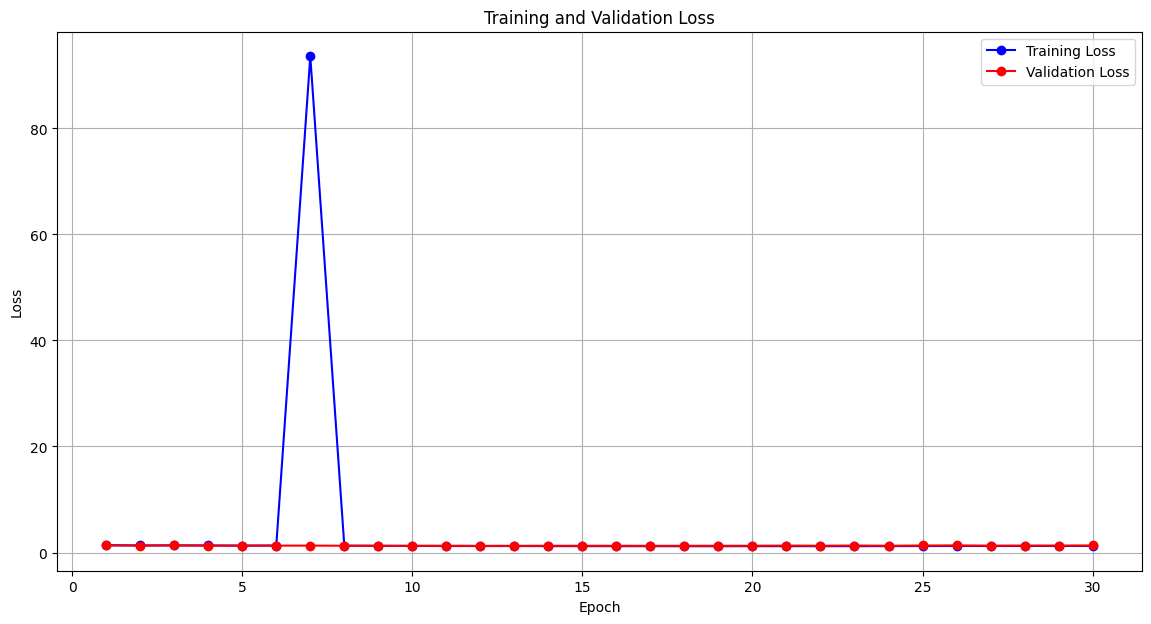

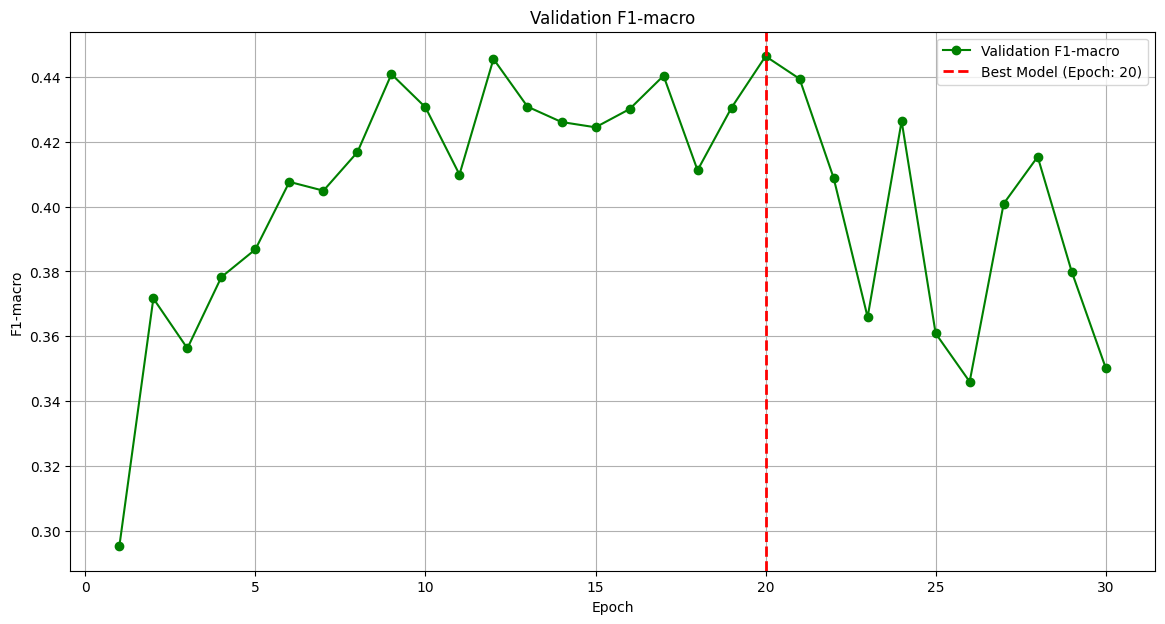

In [19]:
# loss
plt.figure(figsize=(14, 7))
plt.plot(range(1, len(history_cnn['train_loss'])+1), history_cnn['train_loss'], 'bo-', label='Training Loss')
plt.plot(range(1, len(history_cnn['val_loss'])+1), history_cnn['val_loss'], 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# f1-macro
plt.figure(figsize=(14, 7))
plt.plot(range(1, len(history_cnn['val_f1'])+1), history_cnn['val_f1'], 'go-', label='Validation F1-macro')
best_epoch = history_cnn['val_f1'].index(max(history_cnn['val_f1'])) + 1
plt.axvline(x=best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Model (Epoch: {best_epoch})')
plt.title('Validation F1-macro')
plt.xlabel('Epoch')
plt.ylabel('F1-macro')
plt.legend()
plt.grid(True)

## Baseline CNN Test Evaluation

=======  Baseline CNN model evaluation on TEST SET  =======
Test Loss: 1.26710915406545
Test Accuracy: 0.43533333333333335
Test macro F1: 0.41927698726422025
Test Confusion matrix:
[168  93  43  71]
[ 41 224  45  65]
[ 75 133  65 102]
[ 49  94  36 196]



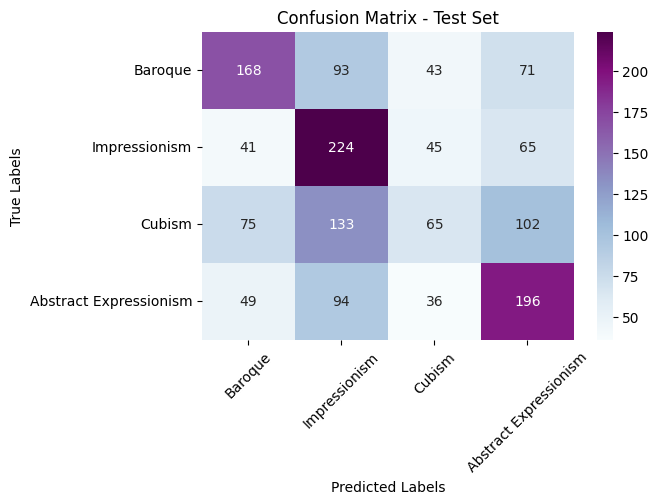

| Model | Parameters | Val Acc | Val macro F1 | Test Acc | Test macro F1 |
| :--- | :---: | :---: | :---: | :---: | :---: |
| Baseline CNN | 34096452 | 46.07% | 44.64% | 43.53% | 0.4193 |


In [20]:
# best baseline cnn evaluation on test set

best_baseline_cnn = BaselineCNN().to(device)
best_baseline_cnn.load_state_dict(torch.load(best_model_path_cnn))

test_loss, test_acc, test_f1, test_cm = evaluate(best_baseline_cnn, test_dataloader, criterion)

print("=======  Baseline CNN model evaluation on TEST SET  =======")
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_acc}")
print(f"Test macro F1: {test_f1}")
print(f"Test Confusion matrix:")
for row in test_cm:
    print(row)
print('')

class_names = ['Baroque', 'Impressionism', 'Cubism', 'Abstract Expressionism']

plt.figure(figsize=(6, 4))
sns.heatmap(test_cm, annot=True, fmt='d', cmap='BuPu',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

# metrics
print("| Model | Parameters | Val Acc | Val macro F1 | Test Acc | Test macro F1 |")
print("| :--- | :---: | :---: | :---: | :---: | :---: |")
best_epoch_idx = history_cnn['val_f1'].index(max(history_cnn['val_f1']))
val_acc_at_best_f1 = history_cnn['val_acc'][best_epoch_idx]
max_val_f1 = max(history_cnn['val_f1'])
total_params = sum(p.numel() for p in best_baseline_cnn.parameters())
print(f"| Baseline CNN | {total_params} | {val_acc_at_best_f1*100:.2f}% | {max_val_f1*100:.2f}% | {test_acc*100:.2f}% | {test_f1:.4f} |")

## CNN with Padding and Pooling

In [21]:
class PoolingCNN(nn.Module):
    def __init__(self):
        super(PoolingCNN, self).__init__()

        # every convolutional layer (with kernel_size=5 and padding=2) keeps the resolution the same but changes the number of channels (3->16->32...)
        # every max_pooling layer (with kernel_size=2) keeps the number of channels the same but halves both dimensions (1/4 of the resolution: 32x32->16x16->8x8...)

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5, padding=2)
        self.pool1 = nn.MaxPool2d(kernel_size=2)

        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, padding=2)
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5, padding=2)
        self.pool3 = nn.MaxPool2d(kernel_size=2)

        self.conv4 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=5, padding=2)
        self.pool4 = nn.MaxPool2d(kernel_size=2)

        self.fc1 = nn.Linear(in_features=128*2*2, out_features=1024)
        self.fc2 = nn.Linear(in_features=1024, out_features=256)
        self.fc3 = nn.Linear(in_features=256, out_features=32)
        self.fc4 = nn.Linear(in_features=32, out_features=4)

    def forward(self, x):
        x = self.pool1(self.conv1(x))
        x = self.pool2(self.conv2(x))
        x = self.pool3(self.conv3(x))
        x = self.pool4(self.conv4(x))

        x = x.view(x.size(0), -1)

        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc3(x)
        x = self.fc4(x)

        return x

pooling_cnn_model = PoolingCNN().to(device)
print(pooling_cnn_model)
print(f"Total parameters: {sum(p.numel() for p in pooling_cnn_model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in pooling_cnn_model.parameters() if p.requires_grad):,}")

PoolingCNN(
  (conv1): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=512, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=32, bias=True)
  (fc4): Linear(in_features=32, out_features=4, bias=True)
)
Total parameters: 1,066,308
Trainable parameters: 1,066,308


## Padding and Pooling CNN Training

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

pooling_optimizer = Adam(pooling_cnn_model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

EPOCHS = 30
history_pooling = {
    'train_loss' : [],
    'train_acc' : [],
    'val_loss' : [],
    'val_acc' : [],
    'val_f1' : []
}

best_val_f1_pooling_cnn = -1
best_model_path_pooling_cnn = 'best_pooling_cnn.pth'

print("Starting training for pooling CNN model...")

for epoch in range(EPOCHS):
    print(f"Epoch [{epoch+1}/{EPOCHS}]", end='')
    # train
    train_loss, train_acc = train_one_epoch(pooling_cnn_model, train_dataloader, pooling_optimizer, criterion)
    # evaluate
    val_loss, val_acc, val_f1, val_cm = evaluate(pooling_cnn_model, val_dataloader, criterion)

    history_pooling['train_loss'].append(train_loss)
    history_pooling['train_acc'].append(train_acc)
    history_pooling['val_loss'].append(val_loss)
    history_pooling['val_acc'].append(val_acc)
    history_pooling['val_f1'].append(val_f1)

    if val_f1>best_val_f1_pooling_cnn:
        best_val_f1_pooling_cnn = val_f1
        torch.save(pooling_cnn_model.state_dict(), best_model_path_pooling_cnn)

    # current epoch results
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}% | Val macro F1: {val_f1:.4f}")
    print("-" * 100)

print("Training complete!")

Using device: cuda
Starting training for pooling CNN model...
Epoch [1/30]  Train Loss: 1.2328 | Train Acc: 42.73% | Val Loss: 1.1685 | Val Acc: 48.07% | Val macro F1: 0.4678
----------------------------------------------------------------------------------------------------
Epoch [2/30]  Train Loss: 1.0254 | Train Acc: 56.73% | Val Loss: 0.9681 | Val Acc: 59.00% | Val macro F1: 0.5811
----------------------------------------------------------------------------------------------------
Epoch [3/30]  Train Loss: 0.9145 | Train Acc: 62.15% | Val Loss: 0.8952 | Val Acc: 62.27% | Val macro F1: 0.6227
----------------------------------------------------------------------------------------------------
Epoch [4/30]  Train Loss: 0.7999 | Train Acc: 67.86% | Val Loss: 0.9365 | Val Acc: 61.13% | Val macro F1: 0.6102
----------------------------------------------------------------------------------------------------
Epoch [5/30]  Train Loss: 0.6752 | Train Acc: 73.16% | Val Loss: 0.9834 | Val Acc:

## Padding and Pooling Learning Curves

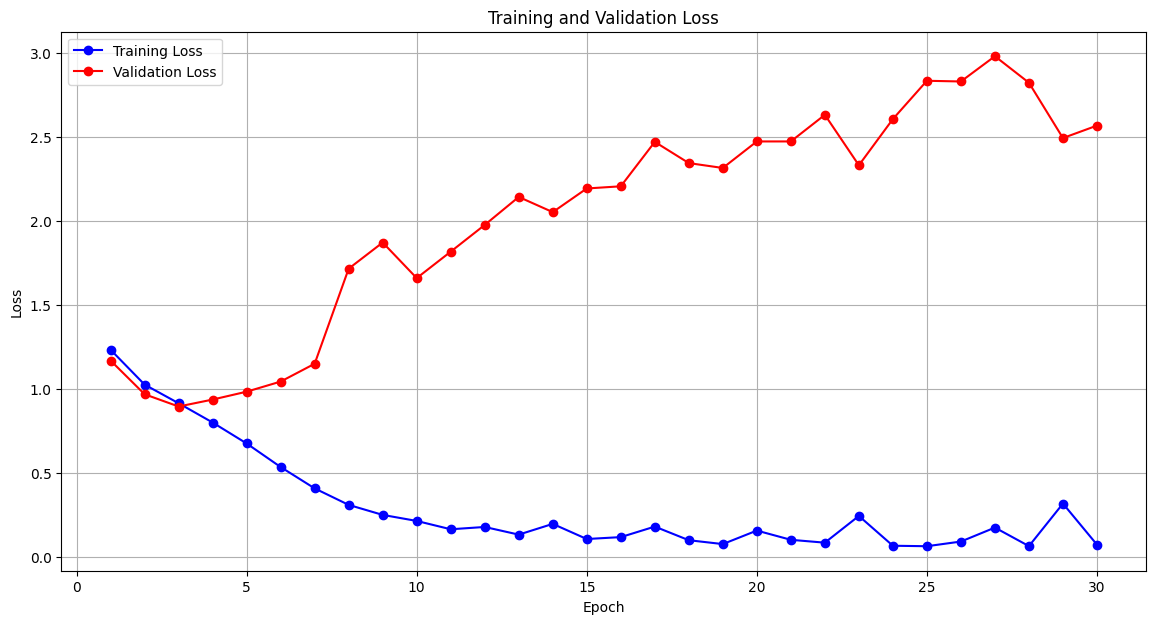

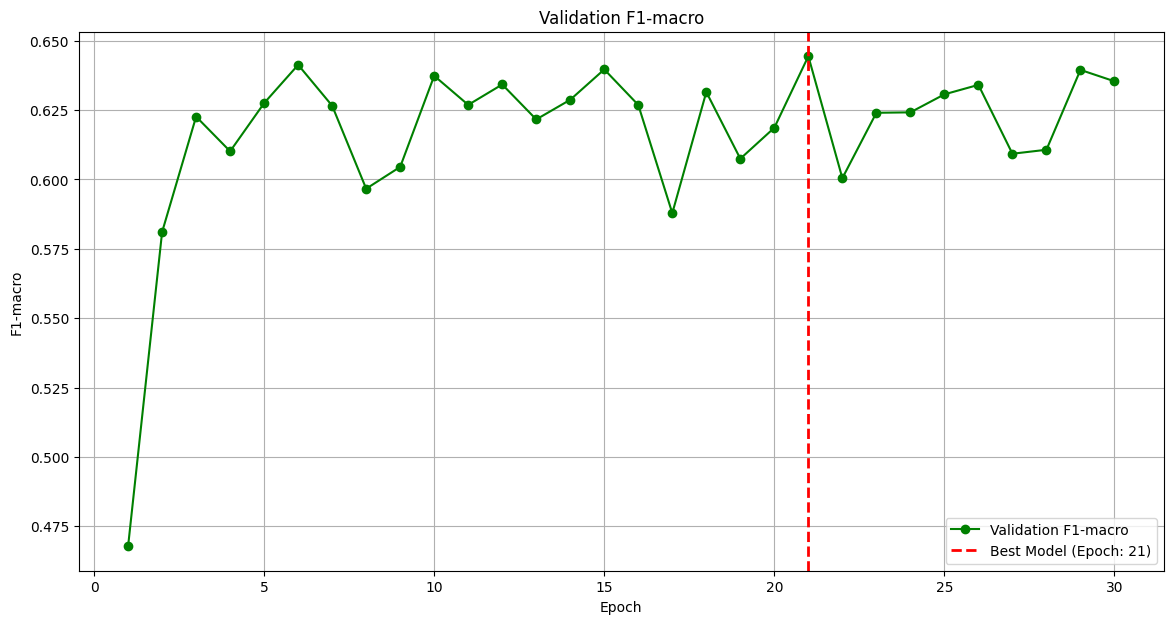

In [23]:
# loss
plt.figure(figsize=(14, 7))
plt.plot(range(1, len(history_pooling['train_loss'])+1), history_pooling['train_loss'], 'bo-', label='Training Loss')
plt.plot(range(1, len(history_pooling['val_loss'])+1), history_pooling['val_loss'], 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# f1-macro
plt.figure(figsize=(14, 7))
plt.plot(range(1, len(history_pooling['val_f1'])+1), history_pooling['val_f1'], 'go-', label='Validation F1-macro')
best_epoch = history_pooling['val_f1'].index(max(history_pooling['val_f1'])) + 1
plt.axvline(x=best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Model (Epoch: {best_epoch})')
plt.title('Validation F1-macro')
plt.xlabel('Epoch')
plt.ylabel('F1-macro')
plt.legend()
plt.grid(True)

## Padding and Pooling CNN Test Evaluation

=======  Pooling CNN model evaluation on TEST SET  =======
Test Loss: 2.3649642537434894
Test Accuracy: 0.6233333333333333
Test macro F1: 0.6266480165704285
Test Confusion matrix:
[235  70  55  15]
[ 30 243  67  35]
[ 15  47 231  82]
[ 15  46  88 226]



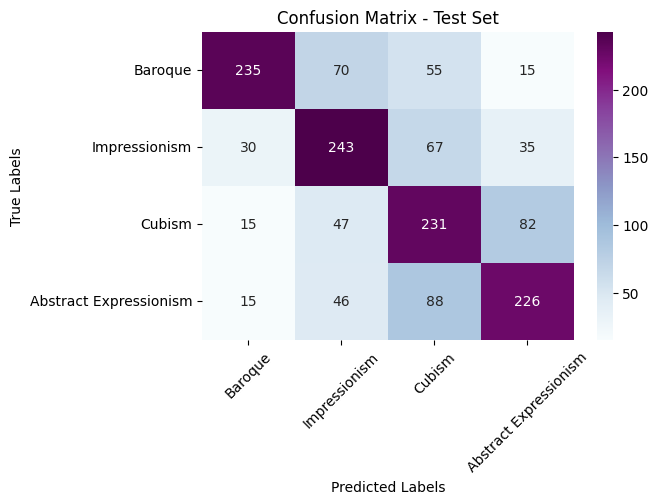

| Model | Parameters | Val Acc | Val macro F1 | Test Acc | Test macro F1 |
| :--- | :---: | :---: | :---: | :---: | :---: |
| Padding and pooling | 1066308 | 64.20% | 64.44% | 62.33% | 0.6266 |


In [24]:
# best pooling cnn model evaluation on test set

best_pooling_cnn = PoolingCNN().to(device)
best_pooling_cnn.load_state_dict(torch.load(best_model_path_pooling_cnn))

test_loss, test_acc, test_f1, test_cm = evaluate(best_pooling_cnn, test_dataloader, criterion)

print("=======  Pooling CNN model evaluation on TEST SET  =======")
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_acc}")
print(f"Test macro F1: {test_f1}")
print(f"Test Confusion matrix:")
for row in test_cm:
    print(row)
print('')

class_names = ['Baroque', 'Impressionism', 'Cubism', 'Abstract Expressionism']

plt.figure(figsize=(6, 4))
sns.heatmap(test_cm, annot=True, fmt='d', cmap='BuPu',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

# metrics
print("| Model | Parameters | Val Acc | Val macro F1 | Test Acc | Test macro F1 |")
print("| :--- | :---: | :---: | :---: | :---: | :---: |")
best_epoch_idx = history_pooling['val_f1'].index(max(history_pooling['val_f1']))
val_acc_at_best_f1 = history_pooling['val_acc'][best_epoch_idx]
max_val_f1 = max(history_pooling['val_f1'])
total_params = sum(p.numel() for p in best_pooling_cnn.parameters())
print(f"| Padding and pooling | {total_params} | {val_acc_at_best_f1*100:.2f}% | {max_val_f1*100:.2f}% | {test_acc*100:.2f}% | {test_f1:.4f} |")

## CNN with ReLU Activations

In [25]:
class ActivationCNN(nn.Module):
    def __init__(self):
        super(ActivationCNN, self).__init__()

        self.relu = nn.ReLU()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5, padding=2)
        self.pool1 = nn.MaxPool2d(kernel_size=2)

        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, padding=2)
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5, padding=2)
        self.pool3 = nn.MaxPool2d(kernel_size=2)

        self.conv4 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=5, padding=2)
        self.pool4 = nn.MaxPool2d(kernel_size=2)


        self.fc1 = nn.Linear(in_features=128*2*2, out_features=1024)
        self.fc2 = nn.Linear(in_features=1024, out_features=256)
        self.fc3 = nn.Linear(in_features=256, out_features=32)
        self.fc4 = nn.Linear(in_features=32, out_features=4)

    def forward(self, x):
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        x = self.pool3(self.relu(self.conv3(x)))
        x = self.pool4(self.relu(self.conv4(x)))

        x = x.view(x.size(0), -1)

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)

        return x

activation_cnn_model = ActivationCNN().to(device)
print(activation_cnn_model)
print(f"Total parameters: {sum(p.numel() for p in activation_cnn_model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in activation_cnn_model.parameters() if p.requires_grad):,}")

ActivationCNN(
  (relu): ReLU()
  (conv1): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=512, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=32, bias=True)
  (fc4): Linear(in_features=32, out_features=4, bias=True)
)
Total parameters: 1,066,308
Trainable parameters: 1,066,308


## Activated CNN Training

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

activation_cnn_optimizer = Adam(activation_cnn_model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

EPOCHS = 30
history_activation = {
    'train_loss' : [],
    'train_acc' : [],
    'val_loss' : [],
    'val_acc' : [],
    'val_f1' : []
}

best_val_f1_activation_cnn = -1
best_model_path_activation_cnn = 'best_activation_cnn.pth'

print("Starting training for activation CNN model...")

gpu_time = -1
cpu_time = -1
start_time = time.time()

for epoch in range(EPOCHS):
    print(f"Epoch [{epoch+1}/{EPOCHS}]", end='')
    # train
    train_loss, train_acc = train_one_epoch(activation_cnn_model, train_dataloader, activation_cnn_optimizer, criterion)
    # evaluate
    val_loss, val_acc, val_f1, val_cm = evaluate(activation_cnn_model, val_dataloader, criterion)

    history_activation['train_loss'].append(train_loss)
    history_activation['train_acc'].append(train_acc)
    history_activation['val_loss'].append(val_loss)
    history_activation['val_acc'].append(val_acc)
    history_activation['val_f1'].append(val_f1)

    if val_f1>best_val_f1_activation_cnn:
        best_val_f1_activation_cnn = val_f1
        torch.save(activation_cnn_model.state_dict(), best_model_path_activation_cnn)

    # current epoch results
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}% | Val macro F1: {val_f1:.4f}")
    print("-" * 100)

end_time = time.time()
if device==torch.device("cpu"):
    cpu_time = end_time - start_time
    print(f"Time: {cpu_time:.4f} seconds")
else:
    gpu_time = end_time - start_time
    print(f"Time: {gpu_time:.4f} seconds")

print("Training complete!")

Using device: cuda
Starting training for activation CNN model...
Epoch [1/30]  Train Loss: 1.2523 | Train Acc: 40.17% | Val Loss: 1.2039 | Val Acc: 41.60% | Val macro F1: 0.3328
----------------------------------------------------------------------------------------------------
Epoch [2/30]  Train Loss: 1.1313 | Train Acc: 47.98% | Val Loss: 1.1012 | Val Acc: 50.00% | Val macro F1: 0.4561
----------------------------------------------------------------------------------------------------
Epoch [3/30]  Train Loss: 1.0466 | Train Acc: 53.68% | Val Loss: 0.9986 | Val Acc: 55.53% | Val macro F1: 0.5409
----------------------------------------------------------------------------------------------------
Epoch [4/30]  Train Loss: 0.9767 | Train Acc: 58.53% | Val Loss: 0.9940 | Val Acc: 58.80% | Val macro F1: 0.5757
----------------------------------------------------------------------------------------------------
Epoch [5/30]  Train Loss: 0.9119 | Train Acc: 62.12% | Val Loss: 0.9083 | Val A

## Activated CNN CPU Benchmark

In [27]:
device = torch.device("cpu")

if cpu_time == -1:
    print(">>> Started training using CPU...")

    activation_cnn_cpu = ActivationCNN().to(device)
    optimizer_activation_cnn_cpu = Adam(activation_cnn_cpu.parameters(), lr=LEARNING_RATE)

    start_time = time.time()
    for epoch in range(EPOCHS):
        train_one_epoch(activation_cnn_cpu, train_dataloader, optimizer_activation_cnn_cpu, criterion)
    end_time = time.time()
    cpu_time = end_time - start_time
    print(f">>> CPU training complete! Time: {cpu_time:.2f} seconds")

# comparison
if gpu_time!=-1 and cpu_time!=-1:
    speedup = cpu_time / gpu_time
    quicker = "GPU" if speedup>1 else "CPU"
    slower = "CPU" if speedup>1 else "GPU"
    print(quicker + f" was {speedup:.4f} times quicker than the " + slower)
else:
    print("No GPU (CUDA) is available for training.")

# for safety
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

>>> Started training using CPU...
>>> CPU training complete! Time: 738.04 seconds
GPU was 9.3195 times quicker than the CPU


## GPU Speedup

This time, GPU usage during the training of the Activation CNN accelerated the process by approximately 8-9 times compared to CPU training, highlighting the advantages of parallel hardware for convolutional workloads.

## Activated CNN Learning Curves

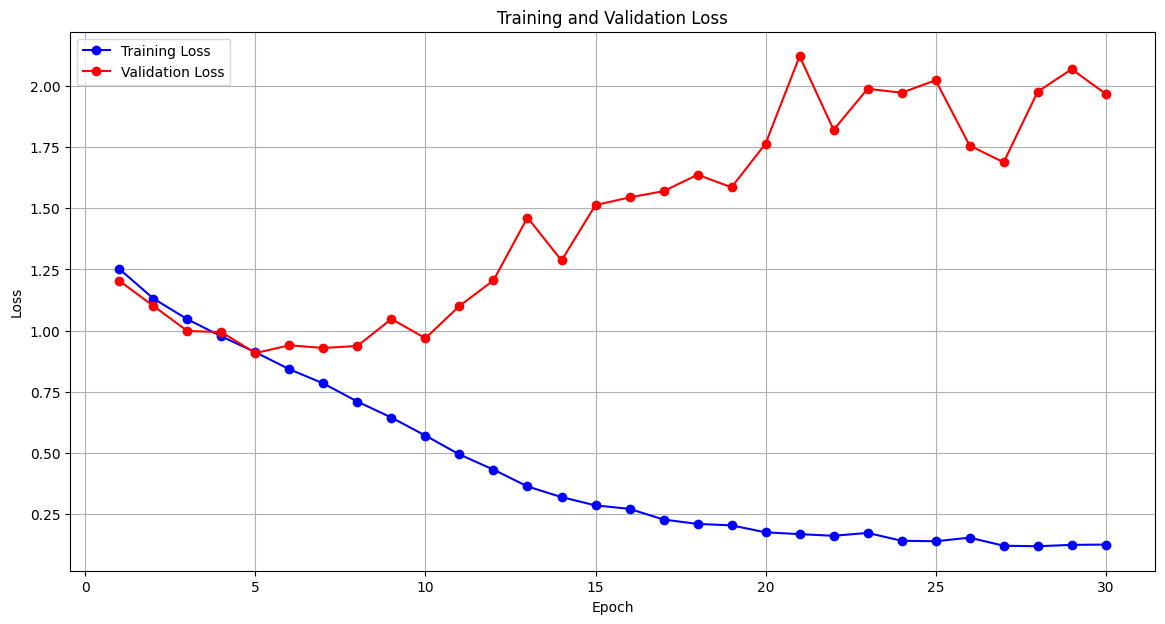

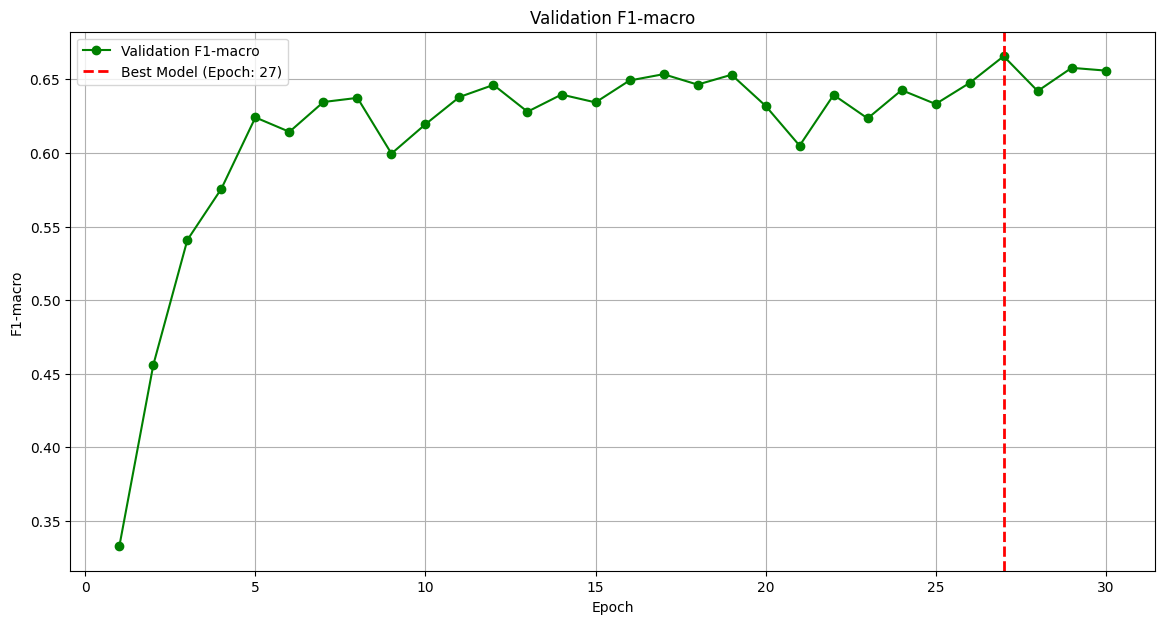

In [28]:
# loss
plt.figure(figsize=(14, 7))
plt.plot(range(1, len(history_activation['train_loss'])+1), history_activation['train_loss'], 'bo-', label='Training Loss')
plt.plot(range(1, len(history_activation['val_loss'])+1), history_activation['val_loss'], 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# f1-macro
plt.figure(figsize=(14, 7))
plt.plot(range(1, len(history_activation['val_f1'])+1), history_activation['val_f1'], 'go-', label='Validation F1-macro')
best_epoch = history_activation['val_f1'].index(max(history_activation['val_f1'])) + 1
plt.axvline(x=best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Model (Epoch: {best_epoch})')
plt.title('Validation F1-macro')
plt.xlabel('Epoch')
plt.ylabel('F1-macro')
plt.legend()
plt.grid(True)

## Activated CNN Test Evaluation

=======  Activation CNN model evaluation on TEST SET  =======
Test Loss: 1.6494059778849284
Test Accuracy: 0.6786666666666666
Test macro F1: 0.6779945365055171
Test Confusion matrix:
[294  30  22  29]
[ 45 239  52  39]
[ 26  53 222  74]
[ 12  50  50 263]



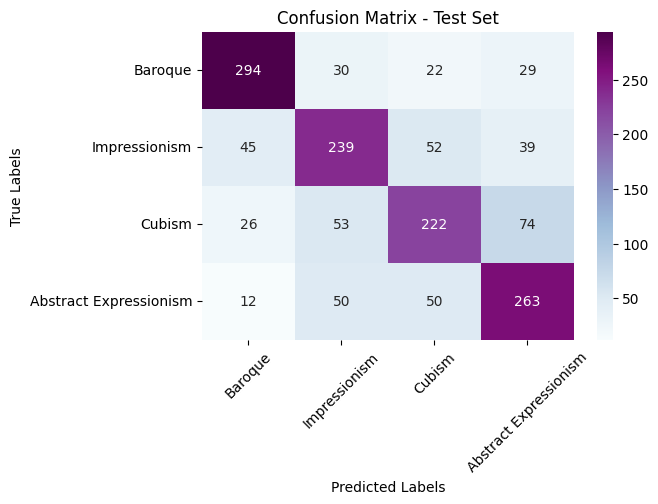

| Model | Parameters | Val Acc | Val macro F1 | Test Acc | Test macro F1 |
| :--- | :---: | :---: | :---: | :---: | :---: |
| Padding, pooling, and ReLU | 1066308 | 66.73% | 66.57% | 67.87% | 0.6780 |


In [29]:
# best activation cnn model evaluation on test set

best_activation_cnn = ActivationCNN().to(device)
best_activation_cnn.load_state_dict(torch.load(best_model_path_activation_cnn))

test_loss, test_acc, test_f1, test_cm = evaluate(best_activation_cnn, test_dataloader, criterion)

cm_cnn = test_cm

print("=======  Activation CNN model evaluation on TEST SET  =======")
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_acc}")
print(f"Test macro F1: {test_f1}")
print(f"Test Confusion matrix:")
for row in test_cm:
    print(row)
print('')

class_names = ['Baroque', 'Impressionism', 'Cubism', 'Abstract Expressionism']

plt.figure(figsize=(6, 4))
sns.heatmap(test_cm, annot=True, fmt='d', cmap='BuPu',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

# metrics
print("| Model | Parameters | Val Acc | Val macro F1 | Test Acc | Test macro F1 |")
print("| :--- | :---: | :---: | :---: | :---: | :---: |")
best_epoch_idx = history_activation['val_f1'].index(max(history_activation['val_f1']))
val_acc_at_best_f1 = history_activation['val_acc'][best_epoch_idx]
max_val_f1 = max(history_activation['val_f1'])
total_params = sum(p.numel() for p in best_activation_cnn.parameters())
print(f"| Padding, pooling, and ReLU | {total_params} | {val_acc_at_best_f1*100:.2f}% | {max_val_f1*100:.2f}% | {test_acc*100:.2f}% | {test_f1:.4f} |")


## CNN Architecture Comparison

| Version | Parameters | Val Acc | Val macro F1 | Test Acc | Test macro F1 |
| :--- | :---: | :---: | :---: | :---: | :---: |
| No padding, pooling or activations | 34096452 | 46.07% | 44.64% | 43.53% | 0.4193 |
| Padding and pooling | 1066308 | 64.20% | 64.44% | 62.33% | 0.6266 |
| Padding, pooling, and ReLU | 1066308 | 66.73% | 66.57% | 67.87% | 0.6780 |

Pooling produced the largest reduction in parameter count by shrinking the feature maps before the fully connected head. Padding and pooling also produced the largest practical improvement in performance, while ReLU added non-linearity without introducing trainable parameters. The no-activation version remains effectively linear through the stack, limiting its ability to model complex visual patterns.

Total number of parameters for baseline FNN model: 397604
Total number of parameters for CNN model with pad, pool and ReLU: 1066308



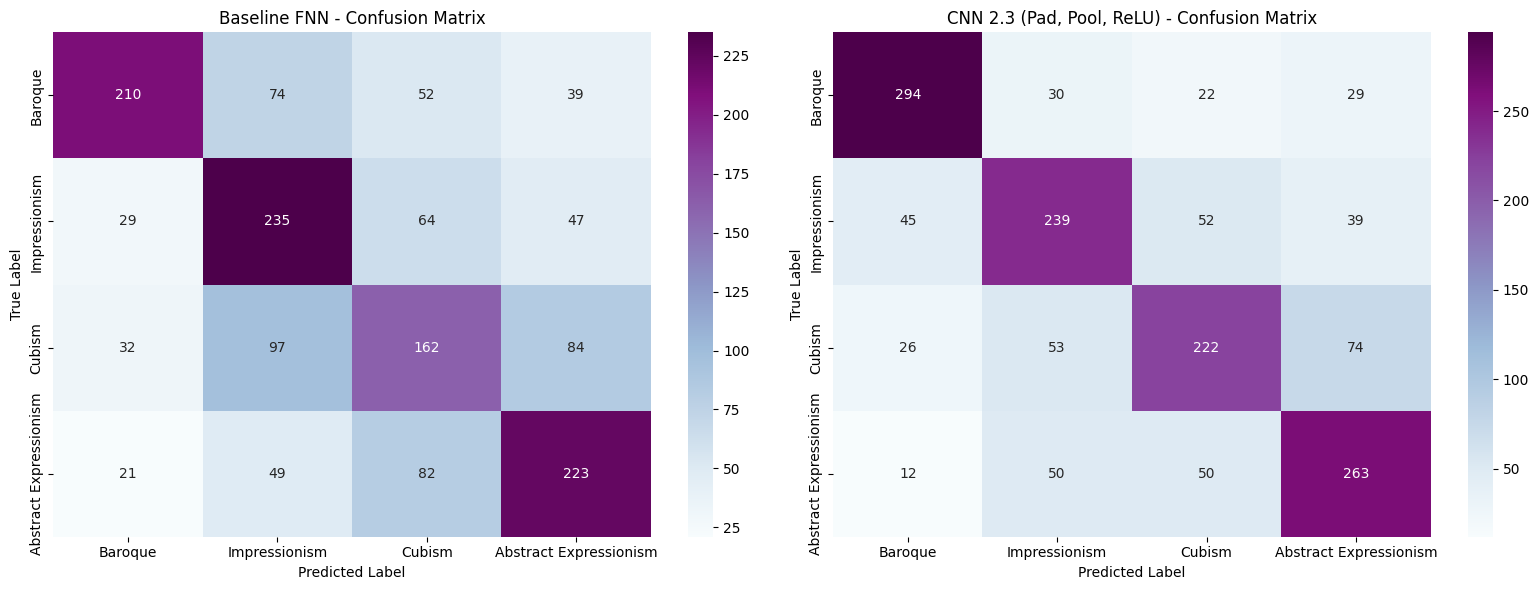

In [30]:
# number of parameters for baseline fnn
total_parameters_fnn = sum(p.numel() for p in best_model.parameters())
print(f"Total number of parameters for baseline FNN model: {total_parameters_fnn}")
total_params = sum(p.numel() for p in best_activation_cnn.parameters())
print(f"Total number of parameters for CNN model with pad, pool and ReLU: {total_params}\n")

# 2 confusion matrices plot
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

sns.heatmap(cm_fnn, annot=True, fmt='d', cmap='BuPu',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Baseline FNN - Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='BuPu',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('CNN 2.3 (Pad, Pool, ReLU) - Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

## CNN vs Feedforward Baseline

| Model | Parameters | Test Macro F1 |
| :--- | :---: | :---: |
| Feedforward baseline | 397604 | 0.5544 |
| CNN with padding, pooling, and ReLU | 1066308 | 0.6780 |

The CNN uses more parameters, yet it performs better because its parameters encode image-specific structure: local receptive fields, spatial organization, and shared convolutional weights. The feedforward model treats the image as a flat vector and cannot efficiently exploit local edges, textures, or translation-tolerant patterns. The CNN therefore achieves a stronger representation even with a larger parameter count.

## Training with Different Optimizers

In [31]:
import torch.optim as optim
import copy

def get_fresh_model():
    # all models should have the same seed
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    model = ActivationCNN().to(device)
    return model

optimizers = {
    # writing  <<"SGD_plain": optim.SGD(get_fresh_model().parameters(), lr=0.01)>>  would create 5 models
    # by the time the dictionary declaration is ran, which would keep all 5 models in memory at once
    # to avoid this, lambda functions were used
    "SGD_plain": lambda params: optim.SGD(params, lr=0.01),
    "SGD_momentum": lambda params: optim.SGD(params, lr=0.01, momentum=0.9),
    "Adam_baseline": lambda params: optim.Adam(params, lr=0.001),
    "RMSprop": lambda params: optim.RMSprop(params, lr=0.001),
    "AdamW": lambda params: optim.AdamW(params, lr=0.001, weight_decay=0.01)
}

optimizer_results = {}
criterion = nn.CrossEntropyLoss()

print("--- Starting comparison between 5 optimizers ---")
for name, opt_factory in optimizers.items():
    # reproducibility
    g.manual_seed(SEED)

    # for model selection
    best_val_f1 = -1.0
    best_val_acc = 0.0
    best_epoch = 0

    # initializing
    model = get_fresh_model()
    optimizer = opt_factory(model.parameters())

    print(f"\nTraining with optimizer: {name}")
    start_time = time.time()
    for epoch in range(EPOCHS):
        train_loss, train_acc = train_one_epoch(model, train_dataloader, optimizer, criterion)
        val_loss, val_acc, val_f1, val_cm = evaluate(model, val_dataloader, criterion)

        # for model selection
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_val_acc = val_acc
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())
    end_time = time.time()

    optimizer_results[name] = {
        "Best_Epoch": best_epoch,
        "Val_Acc": best_val_acc,
        "Val_F1": best_val_f1,
        "Time": end_time - start_time
    }
    print(f"-> Results for {name}:")
    print("| Optimizer | Val Acc | Val macro F1 | Best epoch |")
    print(f"| {name} | {best_val_acc*100:.2f}% | {best_val_f1:.4f} | {best_epoch} |")
    print(f"Training time: {end_time-start_time:.2f}s\n")
    print("-" * 50)

print("\n--- Training with the 5 optimizers complete! ---\n")

--- Starting comparison between 5 optimizers ---

Training with optimizer: SGD_plain
-> Results for SGD_plain:
| Optimizer | Val Acc | Val macro F1 | Best epoch |
| SGD_plain | 59.47% | 0.5808 | 30 |
Training time: 72.80s

--------------------------------------------------

Training with optimizer: SGD_momentum
-> Results for SGD_momentum:
| Optimizer | Val Acc | Val macro F1 | Best epoch |
| SGD_momentum | 66.27% | 0.6621 | 23 |
Training time: 74.64s

--------------------------------------------------

Training with optimizer: Adam_baseline
-> Results for Adam_baseline:
| Optimizer | Val Acc | Val macro F1 | Best epoch |
| Adam_baseline | 66.73% | 0.6666 | 13 |
Training time: 79.07s

--------------------------------------------------

Training with optimizer: RMSprop
-> Results for RMSprop:
| Optimizer | Val Acc | Val macro F1 | Best epoch |
| RMSprop | 66.07% | 0.6607 | 29 |
Training time: 77.95s

--------------------------------------------------

Training with optimizer: AdamW
-> R

## Optimizer Comparison Results

| Optimizer | Val Acc | Val macro F1 | Best epoch |
| :--- | :---: | :---: | :---: |
| SGD plain | 59.47% | 0.5808 | 30 |
| SGD with momentum | 66.27% | 0.6621 | 23 |
| Adam | 66.73% | 0.6666 | 13 |
| RMSprop | 66.07% | 0.6607 | 29 |
| AdamW | 65.80% | 0.6574 | 29 |

## Training with a LR Scheduler

In [32]:
from torch.optim.lr_scheduler import CosineAnnealingLR

best_optimizer_name = max(optimizer_results, key=lambda k: optimizer_results[k]["Val_F1"])
print(f"Applying CosineAnnealingLR scheduler to the best optimizer: {best_optimizer_name}\n")

# reproducibility
g.manual_seed(SEED)

# initializing
model_sched = get_fresh_model()
optimizer_sched = optimizers[best_optimizer_name](model_sched.parameters())

scheduler = CosineAnnealingLR(optimizer_sched, T_max=EPOCHS)

best_val_f1_sched = -1.0
best_val_acc_sched = 0.0
best_epoch_sched = 0
best_model_wts_sched = copy.deepcopy(model_sched.state_dict())

start_time = time.time()
# training with CosineAnnealingLR scheduler
for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model_sched, train_dataloader, optimizer_sched, criterion)
    val_loss, val_acc, val_f1, val_cm = evaluate(model_sched, val_dataloader, criterion)

    scheduler.step()

    # for model selection
    if val_f1 > best_val_f1_sched:
        best_val_f1_sched = val_f1
        best_val_acc_sched = val_acc
        best_epoch_sched = epoch + 1
        best_model_wts_sched = copy.deepcopy(model_sched.state_dict())

end_time = time.time()

print("--- Comparison: No scheduler vs CosineAnnealingLR ---")
print(f"Using Optimizer: {best_optimizer_name}\n")
print("|       Setup       | Val Acc | Val macro F1 | Best Epoch | Time  |")

# results of best optimizer without scheduler
base_stats = optimizer_results[best_optimizer_name]
print(f"| Without Scheduler | {base_stats['Val_Acc']*100:.2f}%  |    {base_stats['Val_F1']:.4f}    |     {base_stats['Best_Epoch']}     | {base_stats['Time']:.1f}s |")

# results after applying scheduler
print(f"| With Scheduler    | {best_val_acc_sched*100:.2f}%  |    {best_val_f1_sched:.4f}    |     {best_epoch_sched}     | {end_time - start_time:.1f}s |")

Applying CosineAnnealingLR scheduler to the best optimizer: Adam_baseline

--- Comparison: No scheduler vs CosineAnnealingLR ---
Using Optimizer: Adam_baseline

|       Setup       | Val Acc | Val macro F1 | Best Epoch | Time  |
| Without Scheduler | 66.73%  |    0.6666    |     13     | 79.1s |
| With Scheduler    | 68.13%  |    0.6817    |     25     | 79.2s |


## Training with Batch Normalization

In [33]:
class BatchNormCNN(nn.Module):
    def __init__(self):
        super(BatchNormCNN, self).__init__()

        self.relu = nn.ReLU()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm2d(num_features=16)
        self.pool1 = nn.MaxPool2d(kernel_size=2)

        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm2d(num_features=32)
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5, padding=2)
        self.bn3 = nn.BatchNorm2d(num_features=64)
        self.pool3 = nn.MaxPool2d(kernel_size=2)

        self.conv4 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=5, padding=2)
        self.bn4 = nn.BatchNorm2d(num_features=128)
        self.pool4 = nn.MaxPool2d(kernel_size=2)


        self.fc1 = nn.Linear(in_features=128*2*2, out_features=1024)
        self.fc2 = nn.Linear(in_features=1024, out_features=256)
        self.fc3 = nn.Linear(in_features=256, out_features=32)
        self.fc4 = nn.Linear(in_features=32, out_features=4)

    def forward(self, x):
        x = self.pool1(self.relu(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu(self.bn3(self.conv3(x))))
        x = self.pool4(self.relu(self.bn4(self.conv4(x))))

        x = x.view(x.size(0), -1)

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)

        return x

print(f"--- Training BatchNormCNN with {best_optimizer_name} and CosineAnnealingLR ---")
# reproducibility
torch.manual_seed(SEED)
g.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

bn_model = BatchNormCNN().to(device)
print(bn_model)
print(f"\nTotal parameters: {sum(p.numel() for p in bn_model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in bn_model.parameters() if p.requires_grad):,}")
bn_optimizer = optimizers[best_optimizer_name](bn_model.parameters())
bn_scheduler = CosineAnnealingLR(bn_optimizer, T_max=EPOCHS)

best_val_f1_bn = -1.0
best_val_acc_bn = 0.0
best_epoch_bn = 0
best_model_wts_bn = copy.deepcopy(bn_model.state_dict())

start_time = time.time()
for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(bn_model, train_dataloader, bn_optimizer, criterion)
    val_loss, val_acc, val_f1, val_cm = evaluate(bn_model, val_dataloader, criterion)

    bn_scheduler.step()

    # for model selection
    if val_f1 > best_val_f1_bn:
        best_val_f1_bn = val_f1
        best_val_acc_bn = val_acc
        best_epoch_bn = epoch + 1
        best_model_wts_bn = copy.deepcopy(bn_model.state_dict())
end_time = time.time()

print("\n------- RESULTS -------")
print("| Model Configuration | Val Acc | Val macro F1 | Best Epoch |")
print(f"| Baseline (Best Opt: {best_optimizer_name}) | {optimizer_results[best_optimizer_name]['Val_Acc']*100:.2f}% | {optimizer_results[best_optimizer_name]['Val_F1']:.4f} | {optimizer_results[best_optimizer_name]['Best_Epoch']} |")
print(f"| {best_optimizer_name} + Cosine Scheduler | {best_val_acc_sched*100:.2f}% | {best_val_f1_sched:.4f} | {best_epoch_sched} |")
print(f"| BatchNorm + {best_optimizer_name} + Cosine Scheduler | {best_val_acc_bn*100:.2f}% | {best_val_f1_bn:.4f} | {best_epoch_bn} |\n")
print(f"Total training time for BatchNorm CNN with scheduler and the best optimizer: {end_time - start_time:.2f}s")

--- Training BatchNormCNN with Adam_baseline and CosineAnnealingLR ---
BatchNormCNN(
  (relu): ReLU()
  (conv1): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, t

## Scheduler and Batch Normalization Results

| Model Configuration | Val Acc | Val macro F1 | Best Epoch |
| :--- | ---: | ---: | ---: |
| Baseline (Best Opt: Adam) | 66.73% | 0.6666 | 13 |
| Adam + Cosine Scheduler | 68.13% | 0.6817 | 25 |
| BatchNorm + Adam + Cosine Scheduler | 73.20% | 0.7305 | 29 |

## CNN with BatchNorm+Adam+Cosine_LR_Scheduler evaluation on Test set

=======  CNN with BatchNorm+Adam+Cosine_LR_Scheduler evaluation on TEST SET  =======
Test Loss: 1.9657079451878865
Test Accuracy: 0.73
Test macro F1: 0.7306511385384741
Test Confusion matrix:
[307  34  25   9]
[ 32 260  52  31]
[ 20  37 269  49]
[ 15  25  76 259]



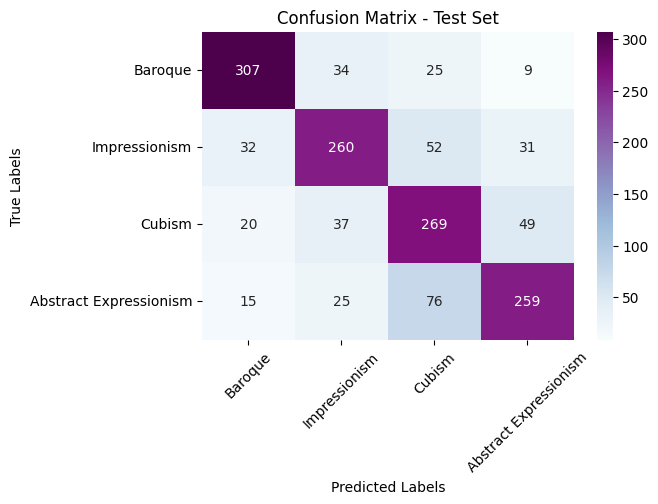

In [34]:
# best model evaluation on test set
bn_model.load_state_dict(best_model_wts_bn)
test_loss_bn, test_acc_bn, test_f1_bn, test_cm_bn = evaluate(bn_model, test_dataloader, criterion)

print("=======  CNN with BatchNorm+Adam+Cosine_LR_Scheduler evaluation on TEST SET  =======")
print(f"Test Loss: {test_loss_bn}")
print(f"Test Accuracy: {test_acc_bn}")
print(f"Test macro F1: {test_f1_bn}")
print(f"Test Confusion matrix:")
for row in test_cm_bn:
    print(row)
print('')

class_names = ['Baroque', 'Impressionism', 'Cubism', 'Abstract Expressionism']

plt.figure(figsize=(6, 4))
sns.heatmap(test_cm_bn, annot=True, fmt='d', cmap='BuPu',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

# Optimizers, Learning-Rate Scheduling, and Batch Normalization

Adam achieved the strongest optimizer-only result with 66.73% validation accuracy and 0.6666 validation macro F1, while SGD with momentum also got close with 66.27% validation accuracy and 0.6621 validation macro f1. Using Adam as the optimal optimizer from now on, the learning rate scheduler helps the model achieve 68.13% validation accuracy and 0.6817 validation macro f1. Adding batch normalization further improves the model's results to 73.20% validation accuracy and 0.7305 validation macro f1.  
The cosine scheduler starts at the configured learning rate for broad optimization and gradually reduces it throughout training, for more precise convergence.

## Regularization and Data Augmentation

In [35]:
from torchvision import transforms
import torchvision.datasets as datasets

class RegularizedBatchNormCNN(nn.Module):
    def __init__(self, dropout_p=0.0):
        super(RegularizedBatchNormCNN, self).__init__()

        self.relu = nn.ReLU()
        # if p=0, behaves as baseline
        self.dropout = nn.Dropout(p=dropout_p)

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm2d(num_features=16)
        self.pool1 = nn.MaxPool2d(kernel_size=2)

        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm2d(num_features=32)
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5, padding=2)
        self.bn3 = nn.BatchNorm2d(num_features=64)
        self.pool3 = nn.MaxPool2d(kernel_size=2)

        self.conv4 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=5, padding=2)
        self.bn4 = nn.BatchNorm2d(num_features=128)
        self.pool4 = nn.MaxPool2d(kernel_size=2)

        self.fc1 = nn.Linear(in_features=128*2*2, out_features=1024)
        self.fc2 = nn.Linear(in_features=1024, out_features=256)
        self.fc3 = nn.Linear(in_features=256, out_features=32)
        self.fc4 = nn.Linear(in_features=32, out_features=4)

    def forward(self, x):
        x = self.pool1(self.relu(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu(self.bn3(self.conv3(x))))
        x = self.pool4(self.relu(self.bn4(self.conv4(x))))

        x = x.view(x.size(0), -1)

        x = self.dropout(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.relu(self.fc3(x))
        x = self.dropout(x)
        x = self.fc4(x)

        return x

RegularizedBatchNormCNN(
  (relu): ReLU()
  (dropout): Dropout(p=0.0, inplace=False)
  (conv1): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stat

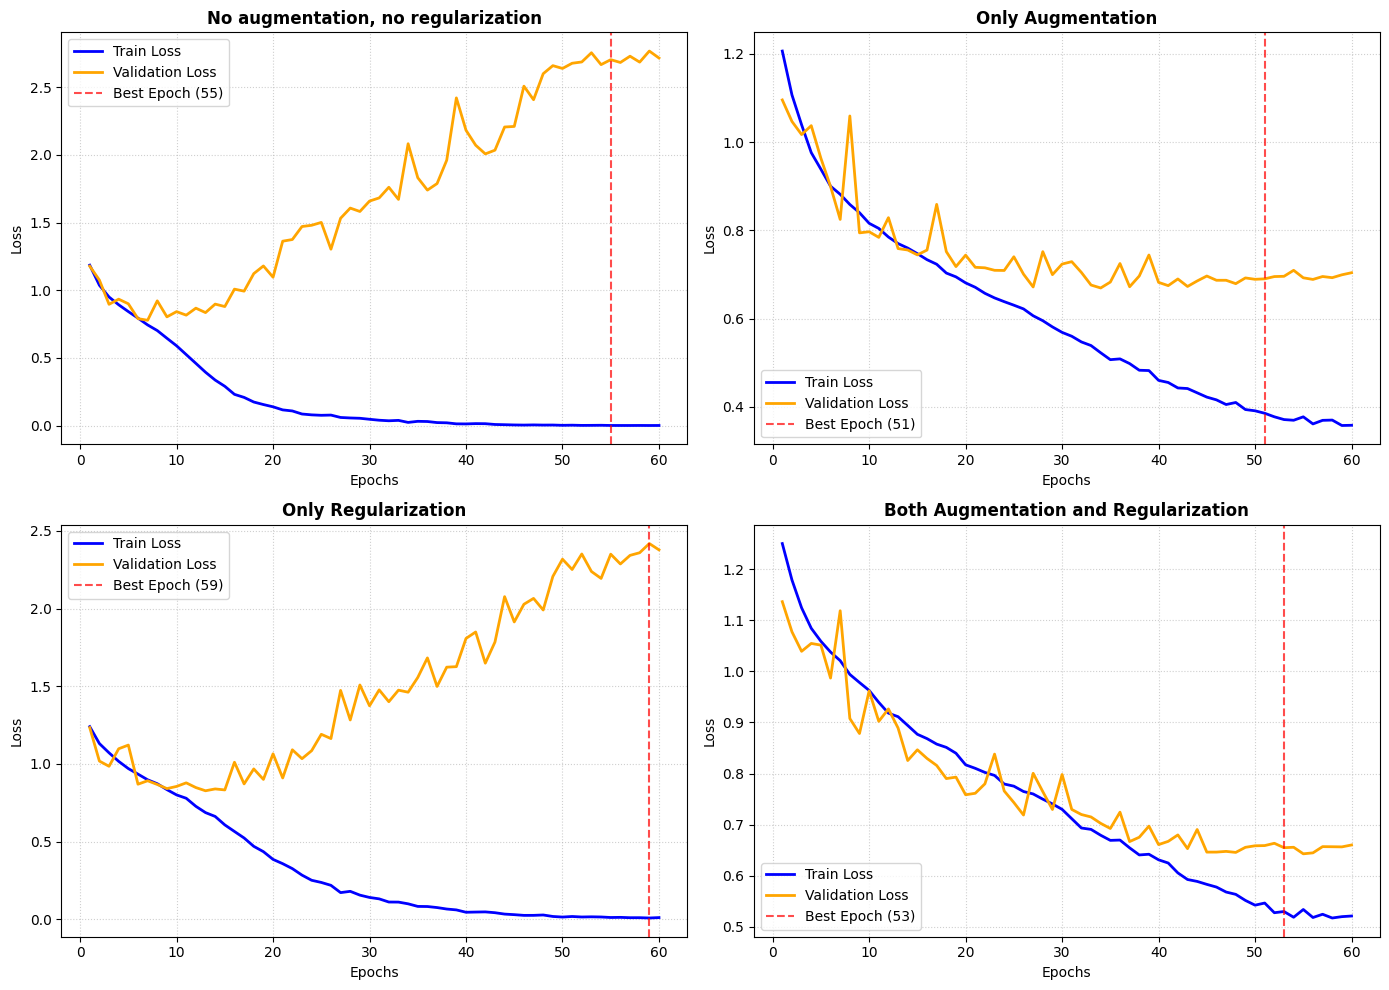


-------------------------------------------------------------------------------------
| Experiment configuration | Best epoch | Val Acc | Val macro F1 | Train-Val gap |
| :--- | :---: | :---: | :---: | :---: |
| No augmentation, no regularization | 55 | 72.13% | 0.7212 | 2.7035 |
| Only Augmentation | 51 | 77.07% | 0.7697 | 0.3046 |
| Only Regularization | 59 | 74.00% | 0.7389 | 2.4111 |
| Both Augmentation and Regularization | 53 | 76.67% | 0.7659 | 0.1250 |
-------------------------------------------------------------------------------------



In [36]:
from torch.utils.data import Dataset

class WikiArtAugmentedDataset(Dataset):
    def __init__(self, x_tensor, y_tensor, transform=None):
        self.x_tensor = x_tensor
        self.y_tensor = y_tensor
        self.transform = transform

    def __len__(self):
        return len(self.x_tensor)

    def __getitem__(self, idx):
        img = self.x_tensor[idx]
        label = self.y_tensor[idx]

        if self.transform:
            img_uint8 = (img * 255.0).to(torch.uint8)
            # apply transformations
            img = self.transform(img_uint8)
        return img, label

# transformations for augmentation
augmented_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ConvertImageDtype(torch.float32)
])

# augmented train datasets
augmented_train_dataset = WikiArtAugmentedDataset(x_train, y_train, transform=augmented_transforms)
plain_train_dataset = WikiArtAugmentedDataset(x_train, y_train, transform=None)

# val/test datasets (no transformation)
val_dataset_clean = WikiArtAugmentedDataset(x_val, y_val, transform=None)
test_dataset_clean = WikiArtAugmentedDataset(x_test, y_test, transform=None)

# replacing dataloaders
val_dataloader_clean  = DataLoader(val_dataset_clean, batch_size=BATCH_SIZE, shuffle=False)
test_dataloader_clean = DataLoader(test_dataset_clean, batch_size=BATCH_SIZE, shuffle=False)

_reference_model = RegularizedBatchNormCNN(dropout_p=0.0).to(device)
print(_reference_model)
print(f"\nTotal parameters: {sum(p.numel() for p in _reference_model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in _reference_model.parameters() if p.requires_grad):,}\n")
del _reference_model


experiments = {
    "No augmentation, no regularization": {"aug": False, "reg": False, "dropout": 0.0, "wd": 0.0},
    "Only Augmentation": {"aug": True,  "reg": False, "dropout": 0.0, "wd": 0.0},
    "Only Regularization": {"aug": False, "reg": True,  "dropout": 0.3, "wd": 1e-4},
    "Both Augmentation and Regularization":     {"aug": True,  "reg": True, "dropout": 0.3, "wd": 1e-4}
}

NEW_EPOCHS = 60
experiment_results = {}
criterion = nn.CrossEntropyLoss()

for exp_name, config in experiments.items():
    print(f"\n>>> Running Experiment: {exp_name}")
    # selecting training dataset
    selected_train_dataset = augmented_train_dataset if config["aug"] else plain_train_dataset

    # reproducibility
    g = torch.Generator()
    g.manual_seed(SEED)

    current_train_loader = DataLoader(
        selected_train_dataset,
        batch_size=train_dataloader.batch_size,
        shuffle=True,
        generator=g,
        num_workers=train_dataloader.num_workers,
        pin_memory=train_dataloader.pin_memory
    )

    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    model = RegularizedBatchNormCNN(dropout_p=config["dropout"]).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=config["wd"])
    scheduler = CosineAnnealingLR(optimizer, T_max=NEW_EPOCHS)

    train_losses, val_losses = [], []
    best_val_f1 = -1.0
    best_val_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())
    best_epoch = 0
    start_time = time.time()
    # training
    for epoch in range(NEW_EPOCHS):
        train_loss, train_acc = train_one_epoch(model, current_train_loader, optimizer, criterion)
        val_loss, val_acc, val_f1, val_cm = evaluate(model, val_dataloader_clean, criterion)

        scheduler.step()

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_val_acc = val_acc
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())
    end_time = time.time()

    experiment_results[exp_name] = {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "Best_Epoch": best_epoch,
        "Val_Acc": best_val_acc,
        "Val_F1": best_val_f1
    }
    print(f"\"{exp_name}\" finished! Best Epoch: {best_epoch} | Val Acc: {best_val_acc*100:.2f}% | Val macro F1: {best_val_f1:.4f} | Training time: {end_time-start_time:.2f}s |")
print("")

use_augmentation = (experiment_results["Only Augmentation"]["Val_F1"] > experiment_results["No augmentation, no regularization"]["Val_F1"] and
                    experiment_results["Both Augmentation and Regularization"]["Val_F1"] > experiment_results["Only Regularization"]["Val_F1"])
if use_augmentation:
    print("\nData augmentation will be used.\n")
    tuning_dataset = augmented_train_dataset
else:
    print("\nData augmentation will not be used.\n")
    tuning_dataset = plain_train_dataset


# train/val loss curves per experiment
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, (exp_name, results) in enumerate(experiment_results.items()):
    epochs_range = range(1, NEW_EPOCHS + 1)
    axes[i].plot(epochs_range, results["train_losses"], label='Train Loss', color='blue', lw=2)
    axes[i].plot(epochs_range, results["val_losses"], label='Validation Loss', color='orange', lw=2)
    axes[i].axvline(x=results["Best_Epoch"], color='red', linestyle='--', alpha=0.7, label=f'Best Epoch ({results["Best_Epoch"]})')

    axes[i].set_title(exp_name, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Epochs')
    axes[i].set_ylabel('Loss')
    axes[i].legend()
    axes[i].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

print("\n" + "-"*85)
print("| Experiment configuration | Best epoch | Val Acc | Val macro F1 | Train-Val gap |")
print("| :--- | :---: | :---: | :---: | :---: |")
for exp_name, res in experiment_results.items():
    print(f"| {exp_name} | {res['Best_Epoch']} | {res['Val_Acc']*100:.2f}% | {res['Val_F1']:.4f} | {res['val_losses'][res['Best_Epoch']-1] - res['train_losses'][res['Best_Epoch']-1]:.4f} |")
print("-"*85 + "\n")


## Regularization and Augmentation Results

| Experiment configuration | Best epoch | Val Acc | Val macro F1 | Train-Val gap |
| :--- | :---: | :---: | :---: | :---: |
| No augmentation, no regularization | 55 | 72.13% | 0.7212 | 2.7035 |
| Only Augmentation | 51 | 77.07% | 0.7697 | 0.3046 |
| Only Regularization | 59 | 74.00% | 0.7389 | 2.4111 |
| Both Augmentation and Regularization | 53 | 76.67% | 0.7659 | 0.1250 |

Data augmentation helped achieve better results as the model is given a range of augmented samples rather than only the originals and regularization also improved generalization. The selected transformations preserve the visual identity of paintings: horizontal flips, small crops, and mild brightness or contrast changes are reasonable, while vertical flips, grayscale conversion, large hue shifts, and strong rotations can alter meaningful artistic cues.  
**Important Note on Regularization:**
It must be clarified that these four preliminary experiments primarily serve to validate the effectiveness of data augmentation. The regularization applied in these runs used a single, arbitrary set of parameters (`dropout=0.3`, `wd=1e-4`).

Regularization will be examined thoroughly and fairly in the following section through hyperparameter tuning (Grid Search) to find the optimal configuration.

## Hyperparameter tuning (Grid Search)

>>> Starting hyperparameter search (dropout x weight_decay)...

>>> Search: dropout=0.1, wd=1e-05
--> Val Acc: 76.47% | Val macro F1: 0.7645 | Best epoch: 52 | Time: 625.54s

>>> Search: dropout=0.1, wd=3.16227766e-05
--> Val Acc: 76.80% | Val macro F1: 0.7671 | Best epoch: 57 | Time: 613.74s

>>> Search: dropout=0.1, wd=0.0001
--> Val Acc: 75.73% | Val macro F1: 0.7564 | Best epoch: 59 | Time: 600.97s

>>> Search: dropout=0.1, wd=0.000316227766
--> Val Acc: 76.27% | Val macro F1: 0.7626 | Best epoch: 56 | Time: 596.82s

>>> Search: dropout=0.1, wd=0.001
--> Val Acc: 75.00% | Val macro F1: 0.7478 | Best epoch: 59 | Time: 598.61s

>>> Search: dropout=0.2, wd=1e-05
--> Val Acc: 76.33% | Val macro F1: 0.7631 | Best epoch: 52 | Time: 606.53s

>>> Search: dropout=0.2, wd=3.16227766e-05
--> Val Acc: 76.47% | Val macro F1: 0.7642 | Best epoch: 60 | Time: 616.90s

>>> Search: dropout=0.2, wd=0.0001
--> Val Acc: 77.20% | Val macro F1: 0.7720 | Best epoch: 60 | Time: 612.30s

>>> Search: dropout

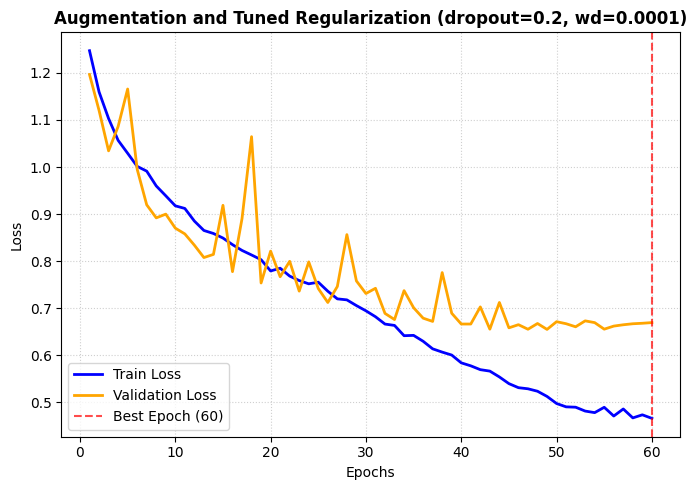


----------------------------------------------------------------------------------------------------
| Experiment configuration | Best epoch | Val Acc | Val macro F1 | Train-Val gap |
| :--- | :---: | :---: | :---: | :---: |
| No augmentation, no regularization | 55 | 72.13% | 0.7212 | 2.7035 |
| Only Augmentation | 51 | 77.07% | 0.7697 | 0.3046 |
| Only Regularization | 59 | 74.00% | 0.7389 | 2.4111 |
| Both Augmentation and Regularization | 53 | 76.67% | 0.7659 | 0.1250 |
| Augmentation and Tuned Regularization (dropout=0.2, wd=0.0001) | 60 | 77.20% | 0.7720 | 0.2037 |
----------------------------------------------------------------------------------------------------



In [37]:
SEARCH_EPOCHS = 60

dropout_values = [0.1, 0.2, 0.3, 0.4, 0.5]
wd_values = [1e-5, 3.16227766e-5, 1e-4, 3.16227766e-4, 1e-3]

search_results = {}
criterion = nn.CrossEntropyLoss()

print(">>> Starting hyperparameter search (dropout x weight_decay)...\n")

for dp in dropout_values:
    for wd in wd_values:
        config_name = f"dropout={dp}, wd={wd}"
        print(f">>> Search: {config_name}")

        g = torch.Generator()
        g.manual_seed(SEED)

        current_train_loader = DataLoader(
            tuning_dataset,
            batch_size=train_dataloader.batch_size,
            shuffle=True,
            generator=g,
            num_workers=train_dataloader.num_workers,
            pin_memory=train_dataloader.pin_memory
        )

        torch.manual_seed(SEED)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(SEED)

        model = RegularizedBatchNormCNN(dropout_p=dp).to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=wd)
        scheduler = CosineAnnealingLR(optimizer, T_max=SEARCH_EPOCHS)

        best_val_f1 = -1.0
        best_val_acc = 0.0
        best_epoch = 0

        start_time = time.time()
        for epoch in range(SEARCH_EPOCHS):
            train_loss, train_acc = train_one_epoch(model, current_train_loader, optimizer, criterion)
            val_loss, val_acc, val_f1, val_cm = evaluate(model, val_dataloader_clean, criterion)

            scheduler.step()

            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                best_val_acc = val_acc
                best_epoch = epoch + 1
        end_time = time.time()

        search_results[config_name] = {
            "dropout": dp,
            "wd": wd,
            "Best_Epoch": best_epoch,
            "Val_Acc": best_val_acc,
            "Val_F1": best_val_f1,
            "Time": end_time - start_time
        }
        print(f"--> Val Acc: {best_val_acc*100:.2f}% | Val macro F1: {best_val_f1:.4f} | Best epoch: {best_epoch} | Time: {end_time-start_time:.2f}s\n")


best_config_name = max(search_results, key=lambda k: search_results[k]["Val_F1"])
best_config = search_results[best_config_name]
print(f"\nOptimal configuration: {best_config_name}.\n")

best_dropout = best_config["dropout"]
best_wd = best_config["wd"]

print("Final training with the optimal configuration...\n")

g = torch.Generator()
g.manual_seed(SEED)

best_train_loader = DataLoader(
    tuning_dataset,
    batch_size=train_dataloader.batch_size,
    shuffle=True,
    generator=g,
    num_workers=train_dataloader.num_workers,
    pin_memory=train_dataloader.pin_memory
)

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

best_reg_model = RegularizedBatchNormCNN(dropout_p=best_dropout).to(device)
print(best_reg_model)
print(f"Total parameters: {sum(p.numel() for p in best_reg_model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in best_reg_model.parameters() if p.requires_grad):,}")

optimizer = optim.Adam(best_reg_model.parameters(), lr=0.001, weight_decay=best_wd)
scheduler = CosineAnnealingLR(optimizer, T_max=NEW_EPOCHS)

best_train_losses, best_val_losses = [], []
best_val_f1_final = -1.0
best_val_acc_final = 0.0
best_model_wts_final = copy.deepcopy(best_reg_model.state_dict())
best_epoch_final = 0

start_time = time.time()
for epoch in range(NEW_EPOCHS):
    train_loss, train_acc = train_one_epoch(best_reg_model, best_train_loader, optimizer, criterion)
    val_loss, val_acc, val_f1, val_cm = evaluate(best_reg_model, val_dataloader_clean, criterion)

    scheduler.step()

    best_train_losses.append(train_loss)
    best_val_losses.append(val_loss)

    if val_f1 > best_val_f1_final:
        best_val_f1_final = val_f1
        best_val_acc_final = val_acc
        best_epoch_final = epoch + 1
        best_model_wts_final = copy.deepcopy(best_reg_model.state_dict())
end_time = time.time()

# best model evaluation on test set
best_reg_model.load_state_dict(best_model_wts_final)
test_loss_final, test_acc_final, test_f1_final, test_cm_final = evaluate(best_reg_model, test_dataloader_clean, criterion)

print(f"\nTuned Regularization finished! "
      f"Best Epoch: {best_epoch_final} | Test Acc: {test_acc_final*100:.2f}% | "
      f"Test macro F1: {test_f1_final:.4f} | Training time: {end_time-start_time:.2f}s\n")

experiment_results[f"Augmentation and Tuned Regularization (dropout={best_dropout}, wd={best_wd})"] = {
    "train_losses": best_train_losses,
    "val_losses": best_val_losses,
    "Best_Epoch": best_epoch_final,
    "Val_Acc": best_val_acc_final,
    "Val_F1": best_val_f1_final,
    "Test_Acc": test_acc_final,
    "Test_F1": test_f1_final
}

# tuned configuration train-val loss plot
plt.figure(figsize=(7, 5))
epochs_range = range(1, NEW_EPOCHS + 1)
plt.plot(epochs_range, best_train_losses, label='Train Loss', color='blue', lw=2)
plt.plot(epochs_range, best_val_losses, label='Validation Loss', color='orange', lw=2)
plt.axvline(x=best_epoch_final, color='red', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch_final})')
plt.title(f"Augmentation and Tuned Regularization (dropout={best_dropout}, wd={best_wd})", fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# updated experiments table
print("\n" + "-"*100)
print("| Experiment configuration | Best epoch | Val Acc | Val macro F1 | Train-Val gap |")
print("| :--- | :---: | :---: | :---: | :---: |")
for exp_name, res in experiment_results.items():
    print(f"| {exp_name} | {res['Best_Epoch']} | {res['Val_Acc']*100:.2f}% | {res['Val_F1']:.4f} | "
          f"{res['val_losses'][res['Best_Epoch']-1] - res['train_losses'][res['Best_Epoch']-1]:.4f} |")
print("-"*100 + "\n")

## Results after hyperparameter tuning

| Experiment configuration | Best epoch | Val Acc | Val macro F1 | Train-Val gap |
| :--- | :---: | :---: | :---: | :---: |
| No augmentation, no regularization | 55 | 72.13% | 0.7212 | 2.7035 |
| Only Augmentation | 51 | 77.07% | 0.7697 | 0.3046 |
| Only Regularization | 59 | 74.00% | 0.7389 | 2.4111 |
| Both Augmentation and Regularization | 53 | 76.67% | 0.7659 | 0.1250 |
| Augmentation and Tuned Regularization (dropout=0.2, wd=0.0001) | 60 | 77.20% | 0.7720 | 0.2037 |

The grid search evaluated five dropout values and five weight decay values using the augmented training set, Adam, and a cosine learning-rate scheduler. The best configuration used dropout=0.2 and weight decay=0.0001, achieving the highest validation F1 among the evaluated configurations.  
The tuned configuration improved the validation macro F1 over the previous data augmentation and regularization setup from 0.7659 to 0.7720. Its train-validation loss gap was not the smallest, but the train-val loss plot shows that the model doesn't overfit, but rather seems to generalize very well. The best configuration was selected by validation F1 rather than by the gap alone as this provides a more direct model-selection criterion while still indicating a reasonable level of generalization.

## Best Custom CNN model evaluation on Test set

=======  Best custom CNN model evaluation on TEST SET  =======
Test Loss: 0.7325915203094483
Test Accuracy: 0.736
Test macro F1: 0.7364834685159944
Test Confusion matrix:
[320  26  20   9]
[ 36 262  56  21]
[ 14  33 251  77]
[ 11  20  73 271]



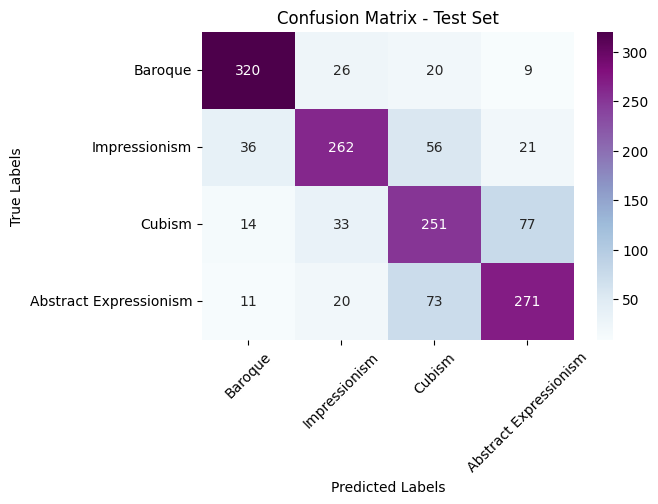

Total parameters: 1,066,788
Trainable parameters: 1,066,788


In [38]:
print("=======  Best custom CNN model evaluation on TEST SET  =======")
print(f"Test Loss: {test_loss_final}")
print(f"Test Accuracy: {test_acc_final}")
print(f"Test macro F1: {test_f1_final}")
print(f"Test Confusion matrix:")
for row in test_cm_final:
    print(row)
print('')
class_names = ['Baroque', 'Impressionism', 'Cubism', 'Abstract Expressionism']

plt.figure(figsize=(6, 4))
sns.heatmap(test_cm_final, annot=True, fmt='d', cmap='BuPu',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

print(f"Total parameters: {sum(p.numel() for p in best_reg_model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in best_reg_model.parameters() if p.requires_grad):,}")

## Transfer Learning with a Pre-trained ResNet18

In [39]:
import torchvision.models as models

def process_batch_for_resnet(images, device):
    # upscale from 32x32 to 224x224
    images_large = F.interpolate(images, size=224, mode='bilinear', align_corners=False)

    # ImageNet normalization (mean & std per channel)
    mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)
    images_norm = (images_large - mean) / std

    return images_norm

# new train function for resnet
def train_resnet_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        # pre-processing before input into resnet
        images_processed = process_batch_for_resnet(images, device)

        optimizer.zero_grad()
        outputs = model(images_processed)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / total, correct / total

# new evaluate function for resnet
def evaluate_resnet(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            # pre-processing before input into resnet
            images_processed = process_batch_for_resnet(images, device)

            outputs = model(images_processed)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    total = len(all_labels)
    loss = running_loss / total
    acc = sum([1 for p, l in zip(all_preds, all_labels) if p == l]) / total
    f1 = f1_score(all_labels, all_preds, average='macro')
    cm = confusion_matrix(all_labels, all_preds)

    return loss, acc, f1, cm

# reproducibility
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

resnet18 = models.resnet18(weights="IMAGENET1K_V1")

# freeze all parameters
for p in resnet18.parameters():
    p.requires_grad = False

resnet18.fc = nn.Linear(512, 4)
resnet18 = resnet18.to(device)

print(resnet18)
print(f"Total parameters: {sum(p.numel() for p in resnet18.parameters()):,}")
trainable_params = sum(p.numel() for p in resnet18.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params:,}")

g = torch.Generator()
g.manual_seed(SEED)
resnet_train_dataloader = DataLoader(
    plain_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=g,
    num_workers=2,
    pin_memory=True,
)

optimizer = optim.Adam(resnet18.fc.parameters(), lr=0.001) # only the fc is trained
criterion = nn.CrossEntropyLoss()
RESNET_EPOCHS = 10
best_val_f1 = -1.0
best_model_wts = copy.deepcopy(resnet18.state_dict())

start_time = time.time()

for epoch in range(RESNET_EPOCHS):
    train_loss, train_acc = train_resnet_epoch(resnet18, resnet_train_dataloader, optimizer, criterion, device)
    val_loss, val_acc, val_f1, val_cm = evaluate_resnet(resnet18, val_dataloader_clean, criterion, device)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_wts = copy.deepcopy(resnet18.state_dict())

    print(f"Epoch {epoch+1:02d}/{RESNET_EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | Val macro F1: {val_f1:.4f}")

end_time = time.time()
print(f"\nTraining complete in: {end_time - start_time:.2f}s.")

# best model evaluation on test set
resnet18.load_state_dict(best_model_wts)
test_loss, test_acc, test_f1, test_cm = evaluate_resnet(resnet18, test_dataloader_clean, criterion, device)

print("\n" + "-"*50)
print("RESULTS FROZEN RESNET18 (TEST SET)")
print("-"*50)
print(f"Test Accuracy: {test_acc}")
print(f"Test macro F1: {test_f1}")
print("-"*50 + "\n")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 132MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## Transfer Learning Results

| Model | Test Accuracy | Test macro F1 | Trainable Parameters | Training Time |
| :--- | :---: | :---: | :---: | :---: |
| Feedforward baseline | 55.33% | 0.5544 | 397604 | 42.61s |
| Tuned custom CNN | 73.60% | 0.7365 | 1066788 | s |
| Frozen ResNet18 with linear probe | 76.40% | 0.7643 | 2052 | 142.32s |

The frozen ResNet18 performed best despite training only its final linear layer. Its ImageNet features provide reusable low-level and mid-level visual representations, including edges, color contrasts, shapes, and textures. The tuned custom CNN improved over the previous best configuration after selecting dropout and weight decay on the validation set. Upscaling the 32x32 inputs to 224x224 introduces artifacts, but the pre-trained representation still transfers effectively to this artistic domain.

>>> Extracting first-layer filters from both models...



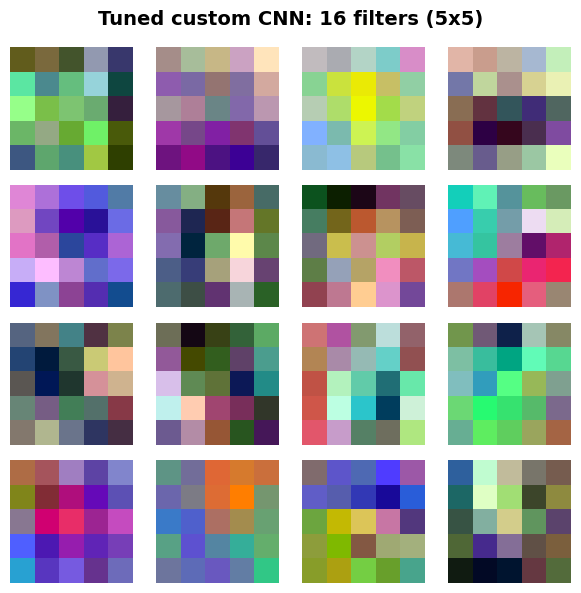

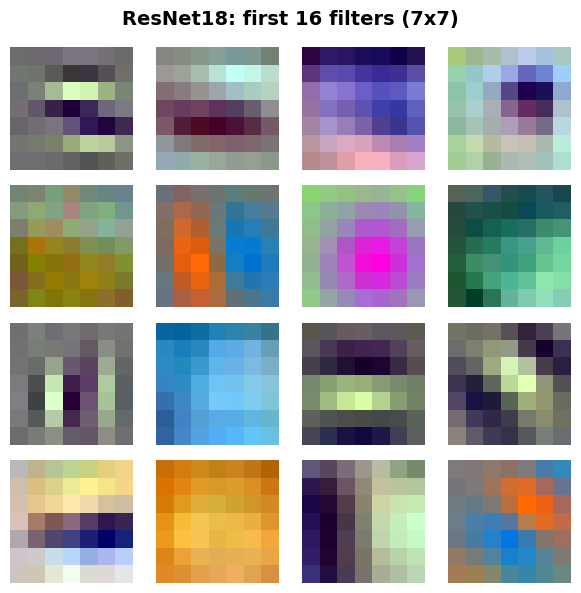


>>> Extracting activation maps for one sample per class...

Class: Baroque



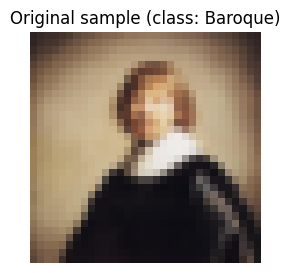

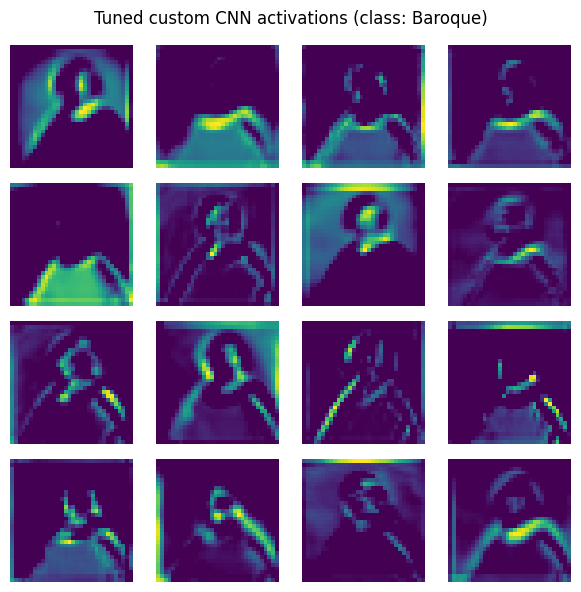

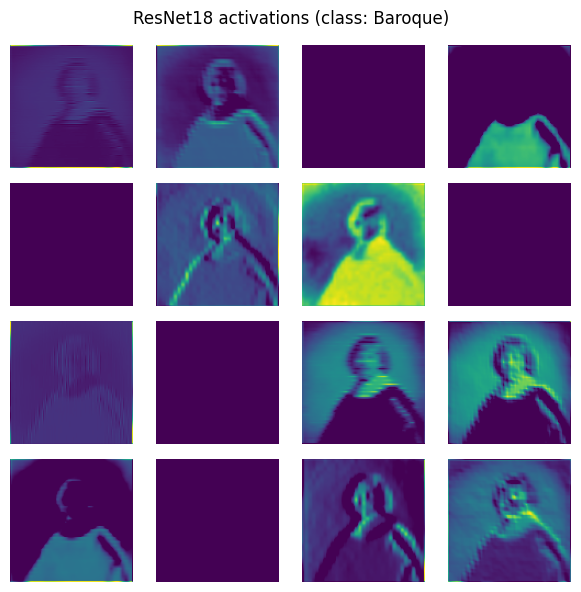




Class: Impressionism



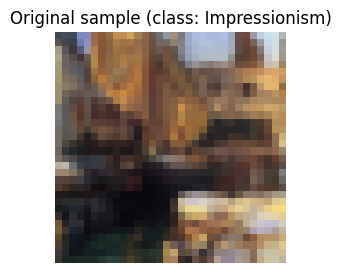

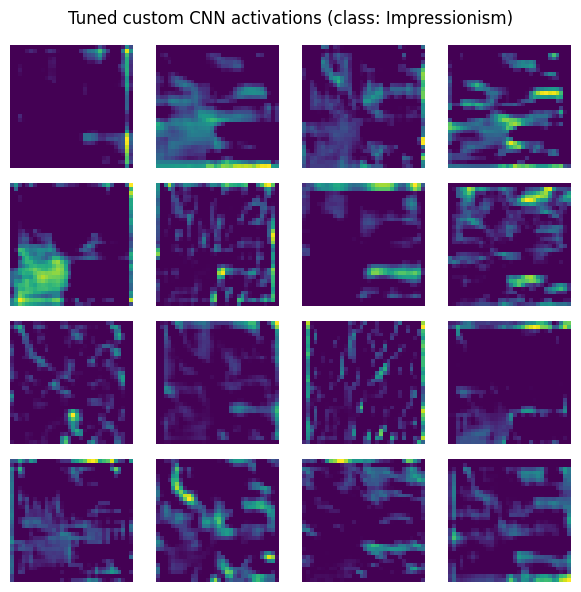

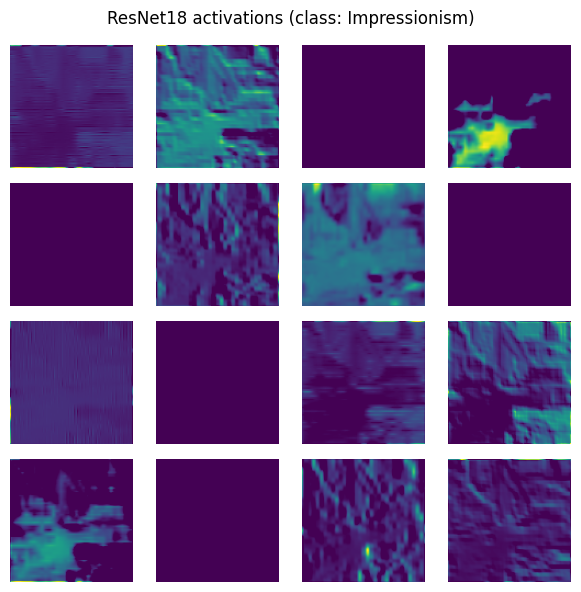




Class: Cubism



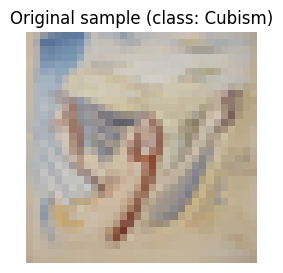

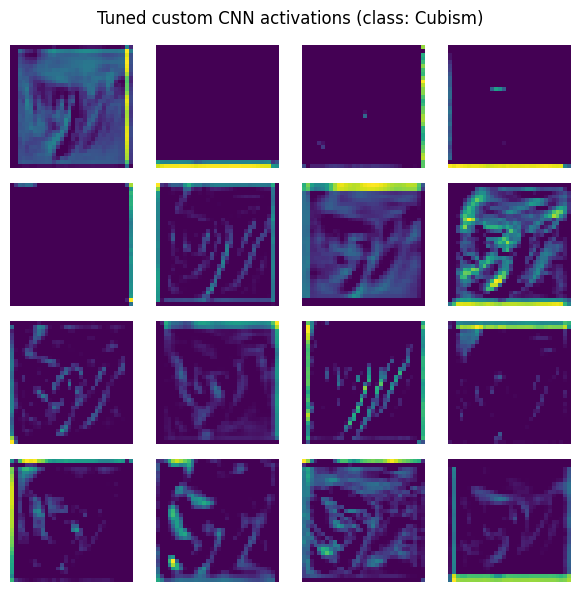

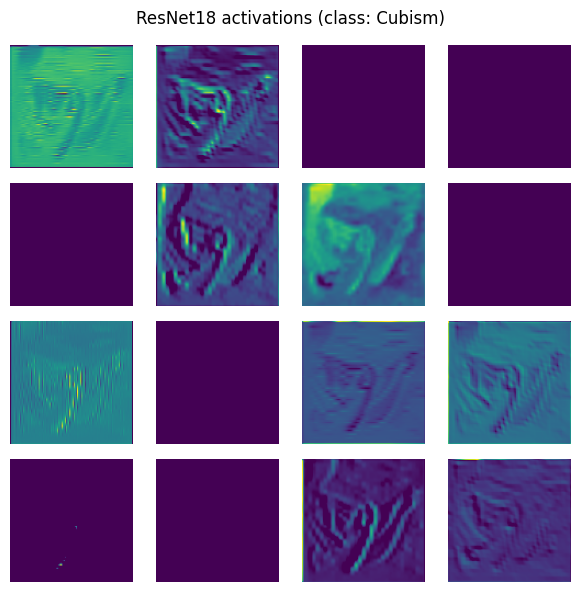




Class: Abstract Expressionism



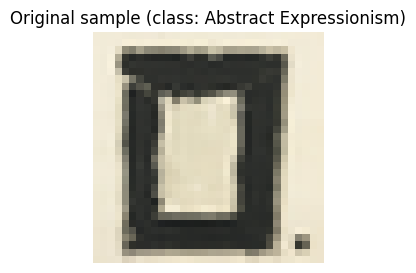

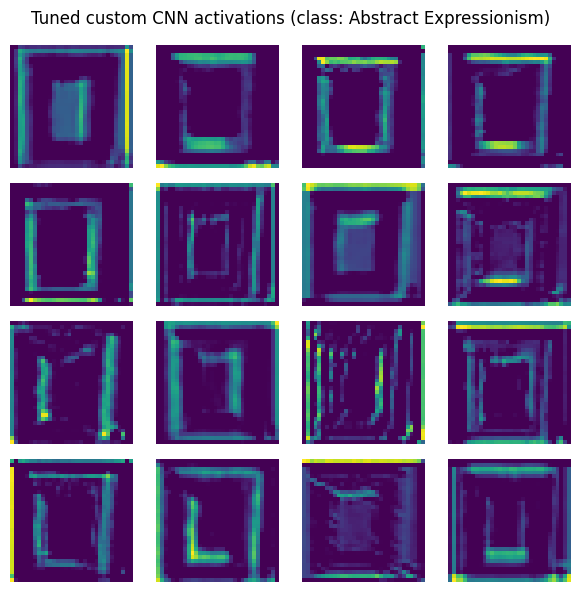

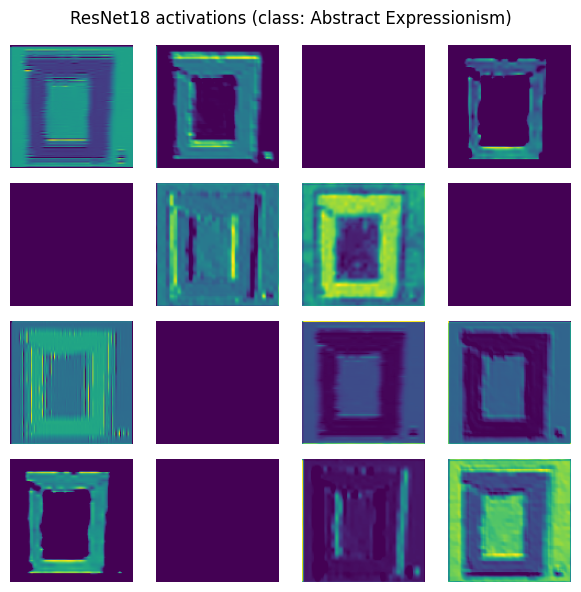

In [40]:
my_custom_cnn = best_reg_model   # tuned custom CNN with the best validation checkpoint
my_resnet = resnet18             # frozen ResNet18 with the best validation checkpoint

my_custom_cnn.eval()
my_resnet.eval()

def plot_filters(weights, title):
    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    for i, ax in enumerate(axes.flatten()):
        f = weights[i].detach().clone()

        # Min-max normalization to [0, 1].
        f_min, f_max = f.min(), f.max()
        f_norm = (f - f_min) / (f_max - f_min + 1e-8)

        # Convert from channels-first to channels-last format.
        ax.imshow(f_norm.permute(1, 2, 0).numpy())
        ax.axis('off')

    plt.tight_layout()
    plt.show()

print(">>> Extracting first-layer filters from both models...\n")
# Custom CNN.
custom_filters = my_custom_cnn.conv1.weight.cpu()
plot_filters(custom_filters, "Tuned custom CNN: 16 filters (5x5)")

# ResNet18.
resnet_filters = my_resnet.conv1.weight.cpu()[:16]
plot_filters(resnet_filters, "ResNet18: first 16 filters (7x7)")


def get_custom_cnn_activations(net, img_tensor, device):
    with torch.no_grad():
        x = img_tensor.unsqueeze(0).to(device)
        x = net.conv1(x)
        x = net.bn1(x)
        x = net.relu(x)
    return x.cpu().squeeze(0)


def get_resnet_activations(net, img_tensor, device):
    with torch.no_grad():
        x = img_tensor.unsqueeze(0).to(device)
        x = process_batch_for_resnet(x, device)
        x = net.conv1(x)
        x = net.bn1(x)
        x = net.relu(x)
    return x.cpu().squeeze(0)[:16]


def plot_activations(activations, title):
    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    fig.suptitle(title, fontsize=12)

    for i, ax in enumerate(axes.flatten()):
        ax.imshow(activations[i].numpy(), cmap='viridis')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Select one random test sample from each class.
random.seed(SEED)
class_samples = {}
indices = list(range(len(test_dataset_clean)))
random.shuffle(indices)

for idx in indices:
    img, label = test_dataset_clean[idx]
    label_index = int(label.item())
    if label_index not in class_samples:
        class_samples[label_index] = img
    if len(class_samples) == 4:
        break

print("\n>>> Extracting activation maps for one sample per class...")
for label_index in sorted(class_samples.keys()):
    img = class_samples[label_index]

    print(f"\nClass: {class_names[label_index]}\n")

    # Original sample.
    plt.figure(figsize=(3, 3))
    plt.title(f"Original sample (class: {class_names[label_index]})")
    plt.imshow(img.permute(1, 2, 0).numpy())
    plt.axis('off')
    plt.show()

    # Custom CNN activations.
    acts_custom = get_custom_cnn_activations(my_custom_cnn, img, device)
    plot_activations(acts_custom, f"Tuned custom CNN activations (class: {class_names[label_index]})")

    # ResNet18 activations.
    acts_resnet = get_resnet_activations(my_resnet, img, device)
    plot_activations(acts_resnet, f"ResNet18 activations (class: {class_names[label_index]})")
    print("\n")

In [41]:
global_end_time = time.time()
print(f"Total runtime: {int((global_end_time-global_start_time) // 60)}m {(global_end_time-global_start_time) % 60:.2f}s")

Total runtime: 329m 23.34s


# Learned Visual Representations

The pre-trained ResNet18 filters are typically clearer, more structured and more interpretable than the filters learned by the custom CNN from the small 32x32 dataset. They often resemble edge detectors, color blobs, and light-dark contrast filters, reflecting the broad visual statistics learned from ImageNet. The custom CNN can still learn useful cues such as contrast for Baroque, geometric edges for Cubism, and color or texture patterns for Impressionism and Abstract Expressionism, but its filters are generally noisier. Compared with the flat-pixel FFN weights, convolutional filters preserve local spatial structure and can detect the same visual pattern at different image locations.